In [1]:
!pip install -q "chronos-forecasting>=1.5.1" 'pandas[pyarrow]' tqdm


In [2]:
# 1. Clone your repo
!git clone https://github.com/Jovi3/Time_Series_Project.git
%cd Time_Series_Project
!git checkout update-tokens

# 2. Install required Python packages
!pip install -q transformers accelerate datasets peft bitsandbytes sentencepiece pandas numpy


fatal: destination path 'Time_Series_Project' already exists and is not an empty directory.
/content/Time_Series_Project
Already on 'update-tokens'
Your branch is up to date with 'origin/update-tokens'.


In [3]:
!cat market_features_master.csv | head

Date,SP500_price,NASDAQ_price,ARKK_price,IVV_price,QQQ_price,SPY_price,VTI_price,SP500_ret,NASDAQ_ret,ARKK_ret,IVV_ret,QQQ_ret,SPY_ret,VTI_ret
2015-01-05,2020.5799560546875,4652.56982421875,17.763418197631836,168.69143676757812,93.51438903808594,168.0037384033203,86.82447052001953,-0.018278105145113743,-0.015706202164824656,-0.024095235400693027,-0.017559646528557793,-0.01466857144556788,-0.01805972874019879,-0.01718233921729584
2015-01-06,2002.6099853515625,4592.740234375,17.696638107299805,167.1715087890625,92.26052856445312,166.42135620117188,85.97370910644531,-0.008893471722946522,-0.012859471669250278,-0.0037594166611994995,-0.009010107493540254,-0.01340820900965467,-0.009418732090054283,-0.009798636357685075
2015-01-07,2025.9000244140625,4650.47021484375,17.777856826782227,169.23965454101562,93.44985961914062,168.4951934814453,86.99960327148438,0.01162984267174294,0.012569833590121648,0.004589499937218022,0.012371400886036943,0.012891006296984697,0.012461365101282817,0.0119326498

In [4]:
# ================================================================
# CHRONOS-T5 SMALL — ZERO-SHOT, L=60, H=1 and H=3 (UNIVARIATE)
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" 'pandas[pyarrow]' tqdm

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from chronos import BaseChronosPipeline

# If you're on Colab and want to save to Drive:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("\n===========================================")
print("🚀 Chronos-T5 Small — Zero-shot (L=60, H=1 & 3)")
print("===========================================\n")

# =========================================================
# 0. MOUNT GOOGLE DRIVE (OPTIONAL BUT RECOMMENDED)
# =========================================================
if IN_COLAB:
    print("📌 Step 0: Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=True)
    DRIVE_SAVE_DIR = "/content/drive/MyDrive/Chronos_ZeroShot_L60"
else:
    print("📌 Step 0: Not in Colab, using local 'chronos_results' dir.")
    DRIVE_SAVE_DIR = "./chronos_results"

os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"   ✔ Results will be saved at: {DRIVE_SAVE_DIR}\n")

# =========================================================
# 1. LOAD DATA
# =========================================================
print("📌 Step 1/7: Loading master dataset...")

# 👉 Adjust this path if needed
CSV_PATH = "market_features_master.csv"

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")

RETURN_COLS = [
    "SP500_ret", "NASDAQ_ret",
    "ARKK_ret", "IVV_ret",
    "QQQ_ret", "SPY_ret", "VTI_ret",
]

print("   ✔ Using return columns (univariate per asset):")
for c in RETURN_COLS:
    print(f"     - {c}")
print()

# =========================================================
# 2. TRAIN / TEST DATE SPLIT (FOR WINDOW FILTERING)
# =========================================================
print("📌 Step 2/7: Setting train / test date ranges...")

train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

print(f"   ✔ Train range: {train_start.date()} → {train_end.date()}")
print(f"   ✔ Test  range: {test_start.date()} → {test_end.date()}\n")

WINDOW = 60
H_MAX  = 3  # we'll build windows for H=3 and reuse for H=1

# =========================================================
# 3. LOAD CHRONOS-T5 SMALL PIPELINE (ZERO-SHOT)
# =========================================================
print("📌 Step 3/7: Loading Chronos-T5 Small pipeline...")

# ❗❗ FIX: Force CPU to avoid device mismatch in bucketize + EOS append
device = "cpu"
dtype  = torch.float32

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=None,        # ensure HuggingFace does NOT move anything to GPU
    torch_dtype=dtype,
)

print("   ✔ Pipeline loaded on CPU")
print(f"   ✔ Using dtype: {dtype}\n")

# =========================================================
# 4. SLIDING WINDOWS (L=60, H=3) + TEST FILTERING
# =========================================================

def build_windows_for_asset(series: pd.Series, asset_name: str):
    """
    Build sliding windows (context length = 60, target length = 3)
    and keep those whose entire 3-step target lies in the test range.
    """
    print(f"   🔹 Building windows for {asset_name}...")
    # Ensure sorted by date & drop NaNs
    s = series.dropna().sort_index()

    dates = s.index.to_numpy()
    vals  = s.values.astype(np.float32)

    contexts = []
    targets  = []
    target_dates = []

    # Build all possible 60→3 windows across the FULL series
    for i in range(len(vals) - WINDOW - H_MAX + 1):
        ctx = vals[i : i + WINDOW]              # length 60
        tgt = vals[i + WINDOW : i + WINDOW + H_MAX]  # length 3
        tgt_dates = dates[i + WINDOW : i + WINDOW + H_MAX]

        # Keep only windows whose target dates fall within [test_start, test_end]
        # (all three steps inside the test range to be strict)
        if (tgt_dates[0] >= test_start) and (tgt_dates[-1] <= test_end):
            contexts.append(ctx)
            targets.append(tgt)
            target_dates.append(tgt_dates)

    if len(contexts) == 0:
        print(f"     ⚠ No valid windows for {asset_name} in test range.")
        return None, None, None

    contexts = np.stack(contexts)   # [N, 60]
    targets  = np.stack(targets)    # [N, 3]
    target_dates = np.stack(target_dates)  # [N, 3]

    print(f"     ✔ Windows for {asset_name}: {contexts.shape[0]} (L=60, H=3)")
    return contexts, targets, target_dates


# =========================================================
# 5. FORECASTING + METRICS FOR H=1 AND H=3
# =========================================================

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

all_metrics = []

for col in RETURN_COLS:
    print("\n===================================")
    print(f"📌 Step 4/7: Processing asset: {col}")
    print("===================================\n")

    series = df[col]
    contexts, targets, target_dates = build_windows_for_asset(series, col)

    if contexts is None:
        continue

    horizons = [1, 3]
    asset_results = {}

    for H in horizons:
        print(f"📌 Step 5/7: Forecasting {col} with H = {H}...")
        preds = []

        for ctx in tqdm(contexts, desc=f"{col} — H={H} forecasting"):
            ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0)

            quantiles, mean = pipeline.predict_quantiles(
                inputs=ctx_tensor,
                prediction_length=H,
                quantile_levels=[0.5],
            )

            pred = mean[0].detach().cpu().numpy()
            preds.append(pred)

        preds = np.stack(preds)

        true_slice = targets[:, :H].reshape(-1)
        pred_slice = preds[:, :H].reshape(-1)

        _mse = mse(true_slice, pred_slice)
        _mae = mae(true_slice, pred_slice)

        print(f"   ✔ {col} — H={H}: MSE = {_mse:.8f}, MAE = {_mae:.8f}")
        asset_results[H] = {
            "preds": preds,
            "mse": _mse,
            "mae": _mae,
        }

    print(f"\n📌 Step 6/7: Saving results for {col}...\n")

    preds_df_dict = {
        "date_t1": target_dates[:, 0],
        "date_t2": target_dates[:, 1],
        "date_t3": target_dates[:, 2],
        "true_t1": targets[:, 0],
        "true_t2": targets[:, 1],
        "true_t3": targets[:, 2],
    }

    for H in horizons:
        preds = asset_results[H]["preds"]
        for step in range(H):
            preds_df_dict[f"pred_H{H}_t{step+1}"] = preds[:, step]

    preds_df = pd.DataFrame(preds_df_dict)
    preds_df.sort_values("date_t1", inplace=True)

    preds_path = os.path.join(
        DRIVE_SAVE_DIR, f"chronos_t5_small_L60_{col}_predictions.csv"
    )
    preds_df.to_csv(preds_path, index=False)

    for H in horizons:
        all_metrics.append({
            "asset": col,
            "horizon": H,
            "mse": asset_results[H]["mse"],
            "mae": asset_results[H]["mae"],
            "num_windows": preds_df.shape[0],
        })

    print(f"   ✔ Predictions saved to: {preds_path}\n")

# =========================================================
# 7. SAVE GLOBAL METRICS TABLE
# =========================================================
print("📌 Step 7/7: Saving global metrics table...\n")

metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df.sort_values(["asset", "horizon"])

metrics_path = os.path.join(
    DRIVE_SAVE_DIR, "chronos_t5_small_L60_metrics_H1_H3.csv"
)
metrics_df.to_csv(metrics_path, index=False)

print("===========================================")
print("✨ DONE — Chronos-T5 Small zero-shot run ✨")
print("===========================================\n")
print(metrics_df)
print(f"\n   ✔ Global metrics saved to: {metrics_path}")



🚀 Chronos-T5 Small — Zero-shot (L=60, H=1 & 3)

📌 Step 0: Mounting Google Drive...
Mounted at /content/drive
   ✔ Results will be saved at: /content/drive/MyDrive/Chronos_ZeroShot_L60

📌 Step 1/7: Loading master dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

   ✔ Using return columns (univariate per asset):
     - SP500_ret
     - NASDAQ_ret
     - ARKK_ret
     - IVV_ret
     - QQQ_ret
     - SPY_ret
     - VTI_ret

📌 Step 2/7: Setting train / test date ranges...
   ✔ Train range: 2015-01-02 → 2020-01-01
   ✔ Test  range: 2021-01-04 → 2022-01-01

📌 Step 3/7: Loading Chronos-T5 Small pipeline...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


   ✔ Pipeline loaded on CPU
   ✔ Using dtype: torch.float32


📌 Step 4/7: Processing asset: SP500_ret

   🔹 Building windows for SP500_ret...
     ✔ Windows for SP500_ret: 250 (L=60, H=3)
📌 Step 5/7: Forecasting SP500_ret with H = 1...


SP500_ret — H=1 forecasting: 100%|██████████| 250/250 [01:01<00:00,  4.10it/s]


   ✔ SP500_ret — H=1: MSE = 0.00007124, MAE = 0.00639126
📌 Step 5/7: Forecasting SP500_ret with H = 3...


...

   ✔ SPY_ret — H=3: MSE = 0.00006783, MAE = 0.00626667

📌 Step 6/7: Saving results for SPY_ret...

   ✔ Predictions saved to: /content/drive/MyDrive/Chronos_ZeroShot_L60/chronos_t5_small_L60_SPY_ret_predictions.csv


📌 Step 4/7: Processing asset: VTI_ret

   🔹 Building windows for VTI_ret...
     ✔ Windows for VTI_ret: 250 (L=60, H=3)
📌 Step 5/7: Forecasting VTI_ret with H = 1...


VTI_ret — H=1 forecasting: 100%|██████████| 250/250 [00:43<00:00,  5.75it/s]


   ✔ VTI_ret — H=1: MSE = 0.00007632, MAE = 0.00662428
📌 Step 5/7: Forecasting VTI_ret with H = 3...


VTI_ret — H=3 forecasting: 100%|██████████| 250/250 [01:07<00:00,  3.73it/s]

   ✔ VTI_ret — H=3: MSE = 0.00007428, MAE = 0.00655749

📌 Step 6/7: Saving results for VTI_ret...

   ✔ Predictions saved to: /content/drive/MyDrive/Chronos_ZeroShot_L60/chronos_t5_small_L60_VTI_ret_predictions.csv

📌 Step 7/7: Saving global metrics table...

✨ DONE — Chronos-T5 Small zero-shot run ✨

         asset  horizon       mse       mae  num_windows
4     ARKK_ret        1  0.000653  0.019595          250
5     ARKK_ret        3  0.000643  0.019633          250
6      IVV_ret        1  0.000070  0.006355          250
7      IVV_ret        3  0.000067  0.006235          250
2   NASDAQ_ret        1  0.000132  0.008621          250
3   NASDAQ_ret        3  0.000132  0.008610          250
8      QQQ_ret        1  0.000136  0.008828          250
9      QQQ_ret        3  0.000135  0.008759          250
0    SP500_ret        1  0.000071  0.006391          250
1    SP500_ret        3  0.000069  0.006279          250
10     SPY_ret        1  0.000069  0.006317          250
11     SPY_re

Loaded metrics:
          asset  horizon       mse       mae  num_windows
0     ARKK_ret        1  0.000653  0.019595          250
2      IVV_ret        1  0.000070  0.006355          250
4   NASDAQ_ret        1  0.000132  0.008621          250
6      QQQ_ret        1  0.000136  0.008828          250
8    SP500_ret        1  0.000071  0.006391          250
10     SPY_ret        1  0.000069  0.006317          250
12     VTI_ret        1  0.000076  0.006624          250
1     ARKK_ret        3  0.000643  0.019633          250
3      IVV_ret        3  0.000067  0.006235          250
5   NASDAQ_ret        3  0.000132  0.008610          250
7      QQQ_ret        3  0.000135  0.008759          250
9    SP500_ret        3  0.000069  0.006279          250
11     SPY_ret        3  0.000068  0.006267          250
13     VTI_ret        3  0.000074  0.006557          250


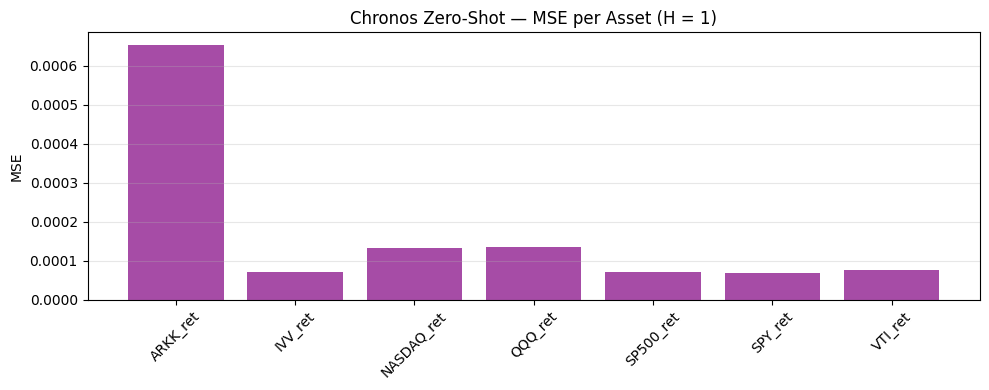

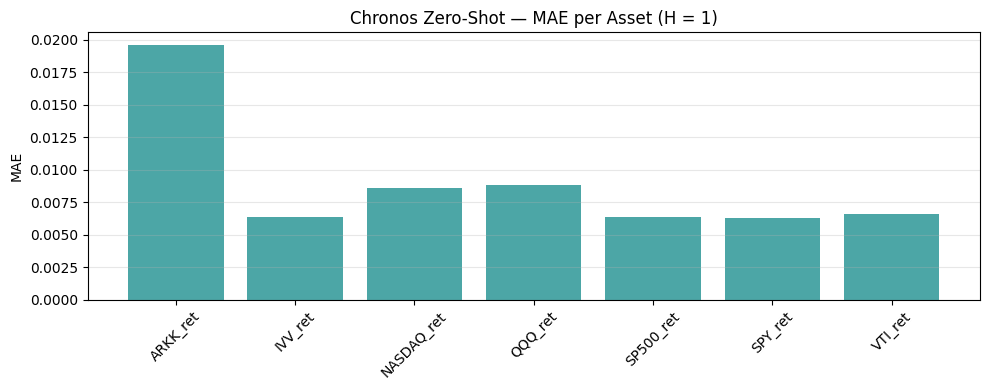

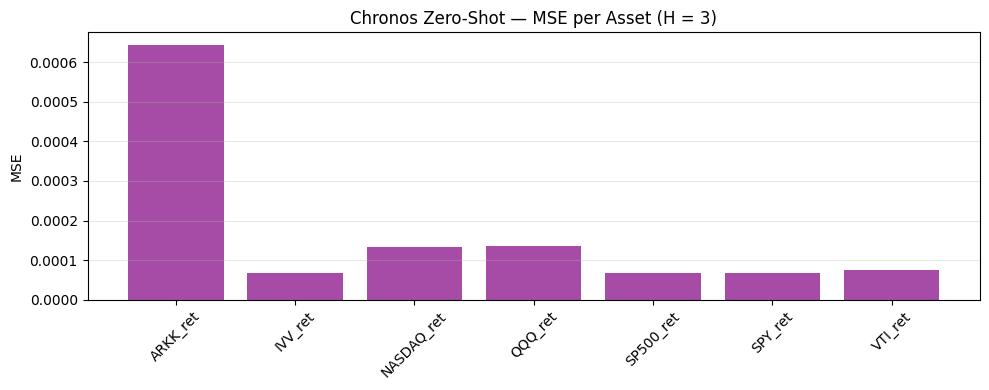

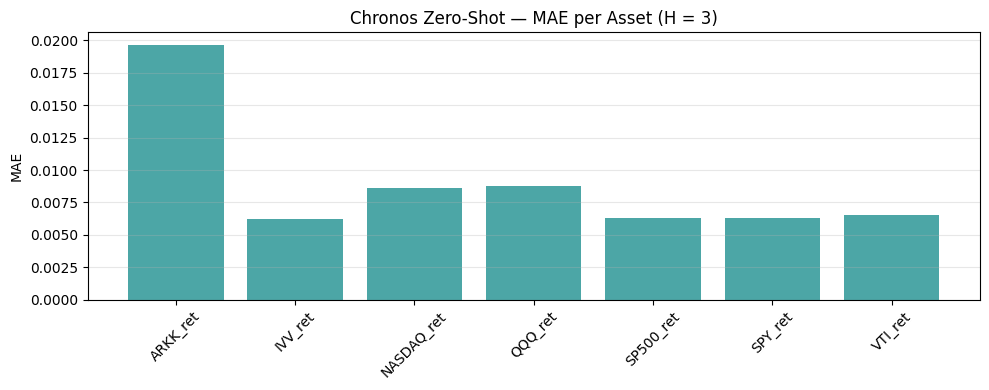

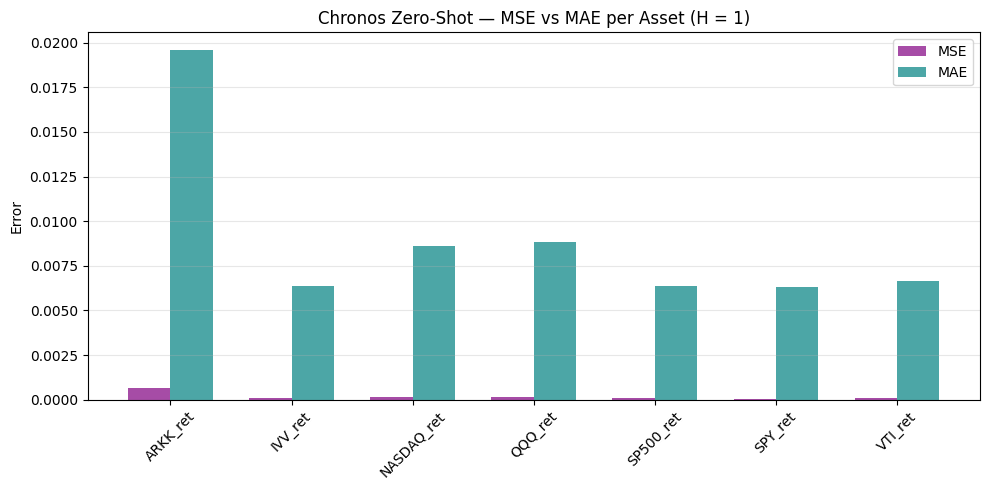

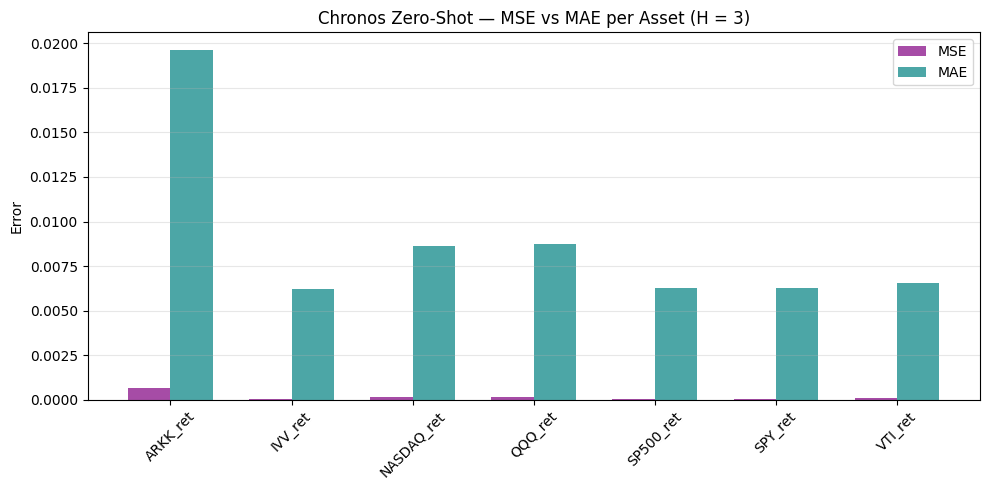

In [5]:
# =======================================
# SIMPLE BAR CHARTS FOR ZERO-SHOT METRICS
# =======================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load metrics CSV
metrics_path = "/content/drive/MyDrive/Chronos_ZeroShot_L60/chronos_t5_small_L60_metrics_H1_H3.csv"
df = pd.read_csv(metrics_path)

# Ensure proper ordering
df = df.sort_values(["horizon", "asset"])

assets = df["asset"].unique()
horizons = [1, 3]

print("Loaded metrics:\n", df)

# ---------------------------------------
# Plot MSE & MAE for each horizon
# ---------------------------------------
for H in horizons:
    sub = df[df["horizon"] == H]

    # ===== MSE Bar Plot =====
    plt.figure(figsize=(10, 4))
    plt.bar(sub["asset"], sub["mse"], color="purple", alpha=0.7)
    plt.title(f"Chronos Zero-Shot — MSE per Asset (H = {H})")
    plt.ylabel("MSE")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===== MAE Bar Plot =====
    plt.figure(figsize=(10, 4))
    plt.bar(sub["asset"], sub["mae"], color="teal", alpha=0.7)
    plt.title(f"Chronos Zero-Shot — MAE per Asset (H = {H})")
    plt.ylabel("MAE")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------
# OPTIONAL: Combined MSE + MAE Side-by-Side per Horizon
# ---------------------------------------
for H in horizons:
    sub = df[df["horizon"] == H].reset_index(drop=True)

    x = np.arange(len(sub))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, sub["mse"], width, label="MSE", color="purple", alpha=0.7)
    plt.bar(x + width/2, sub["mae"], width, label="MAE", color="teal", alpha=0.7)

    plt.xticks(x, sub["asset"], rotation=45)
    plt.title(f"Chronos Zero-Shot — MSE vs MAE per Asset (H = {H})")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [6]:
# ================================================================
# CHRONOS-T5 SMALL — LoRA FINE-TUNING (L=60, H=3, UNIVARIATE)
# One model per asset, train on 2015-01-02..2020-01-01,
# validate on 2020-01-02..2020-12-31.
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" peft "transformers>=4.38.0" accelerate 'pandas[pyarrow]' tqdm

import os
import math
from typing import List, Dict, Any

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

from chronos import BaseChronosPipeline
from peft import LoraConfig, get_peft_model, TaskType
from transformers import Trainer, TrainingArguments

# Try to mount Google Drive (Colab)
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("\n===================================================")
print("🚀 Chronos-T5 Small — LoRA Fine-tuning (L=60, H=3)")
print("===================================================\n")

# =========================================================
# 0. MOUNT GOOGLE DRIVE (OPTIONAL)
# =========================================================
if IN_COLAB:
    print("📌 Step 0: Mounting Google Drive...")
    drive.mount("/content/drive", force_remount=True)
    BASE_SAVE_DIR = "/content/drive/MyDrive/Chronos_Finetune_L60H3"
else:
    print("📌 Step 0: Not in Colab, using local 'chronos_finetune' dir.")
    BASE_SAVE_DIR = "./chronos_finetune"

os.makedirs(BASE_SAVE_DIR, exist_ok=True)
print(f"   ✔ All per-asset adapters will be saved under:\n     {BASE_SAVE_DIR}\n")

# =========================================================
# 1. LOAD DATA
# =========================================================
print("📌 Step 1/7: Loading master dataset...")

# Adjust if needed – assumes CSV is in current working dir
CSV_PATH = "market_features_master.csv"

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")

RETURN_COLS = [
    "SP500_ret", "NASDAQ_ret",
    "ARKK_ret", "IVV_ret",
    "QQQ_ret", "SPY_ret", "VTI_ret",
]

print("   ✔ Using return columns (univariate per asset):")
for c in RETURN_COLS:
    print(f"     - {c}")
print()

# =========================================================
# 2. TRAIN / VAL / TEST SPLITS (BY TARGET DATE)
# =========================================================
print("📌 Step 2/7: Defining date splits for windows...")

# You gave these for train & test:
train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

# We'll use the gap as validation:
val_start   = pd.Timestamp("2020-01-02")
val_end     = pd.Timestamp("2020-12-31")

print(f"   ✔ Train range: {train_start.date()} → {train_end.date()}")
print(f"   ✔ Val   range: {val_start.date()}   → {val_end.date()}")
print(f"   ✔ Test  range: {test_start.date()}  → {test_end.date()}\n")

WINDOW = 60      # L
H = 3            # Training horizon (we'll still evaluate H=1 & H=3 later)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   ✔ Using device: {device}\n")

# =========================================================
# 3. LOAD CHRONOS-T5 SMALL PIPELINE (BASE MODEL)
#    We'll reload per asset to get a fresh base checkpoint.
# =========================================================

def load_chronos_pipeline():
    print("   🔹 Loading Chronos-T5 Small pipeline...")
    dtype = torch.bfloat16 if device == "cuda" else torch.float32

    pipeline = BaseChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map=device,
        torch_dtype=dtype,
    )
    # This is actually a ChronosPipeline under the hood
    print(f"      - inner model type: {type(pipeline.inner_model)}")
    return pipeline


# =========================================================
# 4. SLIDING WINDOW BUILDER
#    (we build full L=60 → H=3 windows, then assign to train/val)
# =========================================================

def build_windows(series: pd.Series):
    """
    Build all sliding windows with context length WINDOW and
    target length H, keeping track of target_end_date per window.
    """
    s = series.dropna().sort_index()

    dates = s.index.to_numpy()
    vals = s.values.astype(np.float32)

    contexts = []
    targets = []
    target_end_dates = []

    for i in range(len(vals) - WINDOW - H + 1):
        ctx = vals[i : i + WINDOW]               # length L=60
        tgt = vals[i + WINDOW : i + WINDOW + H]  # length H=3
        tgt_dates = dates[i + WINDOW : i + WINDOW + H]
        target_end_date = tgt_dates[-1]

        contexts.append(ctx)
        targets.append(tgt)
        target_end_dates.append(target_end_date)

    if len(contexts) == 0:
        return None, None, None

    return (
        np.stack(contexts),               # [N, 60]
        np.stack(targets),                # [N, 3]
        np.array(target_end_dates),       # [N]
    )


# =========================================================
# 5. DATASET CLASS USING CHRONOS TOKENIZER
# =========================================================

class ChronosTimeSeriesDataset(Dataset):
    """
    One asset, fixed L=60, H=3.
    Uses Chronos' MeanScaleUniformBins tokenizer to map
    context + labels into token IDs.
    """

    def __init__(
        self,
        contexts: np.ndarray,        # [N, 60]
        targets: np.ndarray,         # [N, 3]
        end_dates: np.ndarray,       # [N] datetimes
        split: str,
        tokenizer,
        train_end: pd.Timestamp,
        val_start: pd.Timestamp,
        val_end: pd.Timestamp,
    ):
        assert split in {"train", "val"}
        self.tokenizer = tokenizer

        # Filter by split using target END date
        if split == "train":
            mask = end_dates <= train_end
        else:  # "val"
            mask = (end_dates >= val_start) & (end_dates <= val_end)

        self.contexts = contexts[mask]
        self.targets = targets[mask]
        self.end_dates = end_dates[mask]

        print(
            f"      - {split} windows: {self.contexts.shape[0]} "
            f"(out of {contexts.shape[0]} total)"
        )

    def __len__(self):
        return self.contexts.shape[0]

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        ctx = self.contexts[idx]   # [60]
        tgt = self.targets[idx]    # [3]

        # ---- context → tokens ----
        ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0)  # [1, 60]
        token_ids_ctx, attn_ctx, scale = self.tokenizer.context_input_transform(ctx_tensor)
        # token_ids_ctx, attn_ctx, scale: [1, L(+EOS?)] or [1,L], [1,L]

        # ---- label → tokens ----
        # We purposely bypass label_input_transform so we can use H=3
        # regardless of ChronosConfig.prediction_length.
        label_tensor = torch.tensor(tgt, dtype=torch.float32).unsqueeze(0)  # [1, 3]
        label_ids, label_mask, _ = self.tokenizer._input_transform(
            context=label_tensor,
            scale=scale,
        )

        # Add EOS token for labels if Chronos is configured to use EOS
        if getattr(self.tokenizer.config, "use_eos_token", False):
            label_ids, label_mask = self.tokenizer._append_eos_token(
                token_ids=label_ids,
                attention_mask=label_mask,
            )

        # Prepare tensors for Trainer
        input_ids = token_ids_ctx.squeeze(0).long()      # [L_in]
        attention_mask = attn_ctx.squeeze(0).bool()      # [L_in]
        labels = label_ids.squeeze(0).long()             # [L_label]

        # Mask padding in labels with -100 so it's ignored in loss
        pad_id = self.tokenizer.config.pad_token_id
        labels[labels == pad_id] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }



# =========================================================
# 6. CUSTOM COLLATE FN (LEFT-PADDED TO MAX LENGTH IN BATCH)
# =========================================================

def make_collate_fn(tokenizer):
    pad_id = tokenizer.config.pad_token_id

    def collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # Input lengths
        in_lens = [item["input_ids"].shape[0] for item in batch]
        lab_lens = [item["labels"].shape[0] for item in batch]

        max_in = max(in_lens)
        max_lab = max(lab_lens)

        input_ids = []
        attention_masks = []
        labels = []

        for item in batch:
            inp = item["input_ids"]
            mask = item["attention_mask"]
            lab = item["labels"]

            # Left-pad inputs with pad_id
            pad_in = max_in - inp.shape[0]
            if pad_in > 0:
                inp = torch.cat(
                    [torch.full((pad_in,), pad_id, dtype=torch.long), inp],
                    dim=0,
                )
                mask = torch.cat(
                    [torch.zeros(pad_in, dtype=torch.bool), mask],
                    dim=0,
                )
            input_ids.append(inp)
            attention_masks.append(mask)

            # Left-pad labels with -100 (ignored in loss)
            pad_lab = max_lab - lab.shape[0]
            if pad_lab > 0:
                lab = torch.cat(
                    [torch.full((pad_lab,), -100, dtype=torch.long), lab],
                    dim=0,
                )
            labels.append(lab)

        return {
            "input_ids": torch.stack(input_ids),
            "attention_mask": torch.stack(attention_masks),
            "labels": torch.stack(labels),
        }

    return collate_fn


# =========================================================
# 7. LORA CONFIG
# =========================================================

def make_lora_model(base_model):
    """
    Wrap the Chronos inner T5 model with LoRA.
    """
    base_model = base_model.to(device)
    base_model.config.use_cache = False  # important for Trainer + LoRA

    lora_config = LoraConfig(
        r=16,                     # you chose 16
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["q", "v"],
        bias="none",
        task_type=TaskType.SEQ_2_SEQ_LM,
    )


    lora_model = get_peft_model(base_model, lora_config)
    print("      - LoRA trainable params:")
    lora_model.print_trainable_parameters()
    return lora_model


# =========================================================
# 8. TRAIN LOOP PER ASSET
# =========================================================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

for asset in RETURN_COLS:
    print("\n===================================================")
    print(f"🔥 Training LoRA adapter for asset: {asset}")
    print("===================================================\n")

    # ------- Build windows for this asset -------
    series = df[asset]
    contexts, targets, end_dates = build_windows(series)

    if contexts is None:
        print(f"⚠ Skipping {asset} (no valid windows).")
        continue

    print(f"📌 Step 3/7: Windows built for {asset}")
    print(f"   ✔ Total windows: {contexts.shape[0]}\n")

    # ------- Load fresh Chronos pipeline & tokenizer -------
    pipeline = load_chronos_pipeline()
    tokenizer = pipeline.tokenizer
    collate_fn = make_collate_fn(tokenizer)

    # ------- Build train/val datasets -------
    print("📌 Step 4/7: Building train/val datasets...")
    train_ds = ChronosTimeSeriesDataset(
        contexts=contexts,
        targets=targets,
        end_dates=end_dates,
        split="train",
        tokenizer=tokenizer,
        train_end=train_end,
        val_start=val_start,
        val_end=val_end,
    )
    val_ds = ChronosTimeSeriesDataset(
        contexts=contexts,
        targets=targets,
        end_dates=end_dates,
        split="val",
        tokenizer=tokenizer,
        train_end=train_end,
        val_start=val_start,
        val_end=val_end,
    )

    if len(train_ds) == 0 or len(val_ds) == 0:
        print(f"⚠ Not enough windows for train/val for {asset}, skipping.")
        continue

    print(
        f"   ✔ Final sizes → train: {len(train_ds)}, "
        f"val: {len(val_ds)}\n"
    )

    # ------- Prepare LoRA model -------
    print("📌 Step 5/7: Wrapping inner T5 with LoRA...")
    base_model = pipeline.inner_model  # T5 seq2seq model
    lora_model = make_lora_model(base_model)

    # ------- Training args -------
    print("📌 Step 6/7: Setting up Trainer...")
    output_dir = os.path.join(BASE_SAVE_DIR, asset)
    os.makedirs(output_dir, exist_ok=True)
    training_args = TrainingArguments(
        output_dir=output_dir,

        # Batch sizes
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        # Training length
        num_train_epochs=5,

        # Optimizer & LR schedule
        learning_rate=5e-4,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        weight_decay=0.01,
        gradient_accumulation_steps=1,

        # Logging
        logging_strategy="steps",
        logging_steps=50,

        # Saving
        save_strategy="epoch",
        save_total_limit=2,

        # Evaluation
        eval_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        # Reproducibility
        seed=SEED,
        report_to="none",

        # Mixed precision
        bf16=(device == "cuda"),
    )

    def compute_metrics(eval_pred):
        # Optional: we can just report loss for now
        return {}

    trainer = Trainer(
        model=lora_model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
    )

    print(f"   ✔ Starting training for {asset}...\n")
    train_result = trainer.train()
    trainer.save_state()

    # ------- Save LoRA adapter only (small!) -------
    print("📌 Step 7/7: Saving LoRA adapter & logs...\n")
    adapter_dir = os.path.join(output_dir, "lora_adapter")
    os.makedirs(adapter_dir, exist_ok=True)
    lora_model.save_pretrained(adapter_dir)

    # Save a small metadata file with basic info
    meta_path = os.path.join(output_dir, "train_meta.txt")
    with open(meta_path, "w") as f:
        f.write(f"asset={asset}\n")
        f.write(f"L={WINDOW}, H={H}\n")
        f.write(f"train_windows={len(train_ds)}\n")
        f.write(f"val_windows={len(val_ds)}\n")
        f.write(f"output_dir={output_dir}\n")

    print(f"   ✔ Finished {asset}")
    print(f"     - LoRA adapter saved to: {adapter_dir}")
    print(f"     - Meta info saved to: {meta_path}\n")

print("\n===========================================")
print("✨ DONE — LoRA fine-tuning for all assets ✨")
print("===========================================\n")



🚀 Chronos-T5 Small — LoRA Fine-tuning (L=60, H=3)

📌 Step 0: Mounting Google Drive...
Mounted at /content/drive
   ✔ All per-asset adapters will be saved under:
     /content/drive/MyDrive/Chronos_Finetune_L60H3

📌 Step 1/7: Loading master dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

   ✔ Using return columns (univariate per asset):
     - SP500_ret
     - NASDAQ_ret
     - ARKK_ret
     - IVV_ret
     - QQQ_ret
     - SPY_ret
     - VTI_ret

📌 Step 2/7: Defining date splits for windows...
   ✔ Train range: 2015-01-02 → 2020-01-01
   ✔ Val   range: 2020-01-02   → 2020-12-31
   ✔ Test  range: 2021-01-04  → 2022-01-01

   ✔ Using device: cuda


🔥 Training LoRA adapter for asset: SP500_ret

📌 Step 3/7: Windows built for SP500_ret
   ✔ Total windows: 1700

   🔹 Loading Chronos-T5 Small pipeline...
      - inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
📌 Step 4/7: Building trai

Epoch,Training Loss,Validation Loss
1,6.990900,5.141867
2,5.014200,5.009031
3,5.006700,5.006442
4,4.955900,5.002624
5,4.981900,5.002538


📌 Step 7/7: Saving LoRA adapter & logs...

   ✔ Finished SP500_ret
     - LoRA adapter saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/SP500_ret/lora_adapter
     - Meta info saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/SP500_ret/train_meta.txt


🔥 Training LoRA adapter for asset: NASDAQ_ret

📌 Step 3/7: Windows built for NASDAQ_ret
   ✔ Total windows: 1700

   🔹 Loading Chronos-T5 Small pipeline...
      - inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
📌 Step 4/7: Building train/val datasets...
      - train windows: 1195 (out of 1700 total)
      - val windows: 253 (out of 1700 total)
   ✔ Final sizes → train: 1195, val: 253

📌 Step 5/7: Wrapping inner T5 with LoRA...
      - LoRA trainable params:
trainable params: 589,824 || all params: 46,744,064 || trainable%: 1.2618
📌 Step 6/7: Setting up Trainer...
   ✔ Starting training for NASDAQ_ret...



Epoch,Training Loss,Validation Loss
1,7.012800,5.114554
2,5.013300,4.997817
3,5.010800,4.990413
4,4.965500,4.985041
5,4.982000,4.983809


📌 Step 7/7: Saving LoRA adapter & logs...

   ✔ Finished NASDAQ_ret
     - LoRA adapter saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/NASDAQ_ret/lora_adapter
     - Meta info saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/NASDAQ_ret/train_meta.txt


🔥 Training LoRA adapter for asset: ARKK_ret

📌 Step 3/7: Windows built for ARKK_ret
   ✔ Total windows: 1700

   🔹 Loading Chronos-T5 Small pipeline...
      - inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
📌 Step 4/7: Building train/val datasets...
      - train windows: 1195 (out of 1700 total)
      - val windows: 253 (out of 1700 total)
   ✔ Final sizes → train: 1195, val: 253

📌 Step 5/7: Wrapping inner T5 with LoRA...
      - LoRA trainable params:
trainable params: 589,824 || all params: 46,744,064 || trainable%: 1.2618
📌 Step 6/7: Setting up Trainer...
   ✔ Starting training for ARKK_ret...



...

📌 Step 7/7: Saving LoRA adapter & logs...

   ✔ Finished QQQ_ret
     - LoRA adapter saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/QQQ_ret/lora_adapter
     - Meta info saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/QQQ_ret/train_meta.txt


🔥 Training LoRA adapter for asset: SPY_ret

📌 Step 3/7: Windows built for SPY_ret
   ✔ Total windows: 1700

   🔹 Loading Chronos-T5 Small pipeline...
      - inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
📌 Step 4/7: Building train/val datasets...
      - train windows: 1195 (out of 1700 total)
      - val windows: 253 (out of 1700 total)
   ✔ Final sizes → train: 1195, val: 253

📌 Step 5/7: Wrapping inner T5 with LoRA...
      - LoRA trainable params:
trainable params: 589,824 || all params: 46,744,064 || trainable%: 1.2618
📌 Step 6/7: Setting up Trainer...
   ✔ Starting training for SPY_ret...



Epoch,Training Loss,Validation Loss
1,7.004400,5.115507
2,5.010600,5.019472
3,5.007100,5.015544
4,4.958000,5.010109
5,4.982800,5.008784


📌 Step 7/7: Saving LoRA adapter & logs...

   ✔ Finished SPY_ret
     - LoRA adapter saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/SPY_ret/lora_adapter
     - Meta info saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/SPY_ret/train_meta.txt


🔥 Training LoRA adapter for asset: VTI_ret

📌 Step 3/7: Windows built for VTI_ret
   ✔ Total windows: 1700

   🔹 Loading Chronos-T5 Small pipeline...
      - inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
📌 Step 4/7: Building train/val datasets...
      - train windows: 1195 (out of 1700 total)
      - val windows: 253 (out of 1700 total)
   ✔ Final sizes → train: 1195, val: 253

📌 Step 5/7: Wrapping inner T5 with LoRA...
      - LoRA trainable params:
trainable params: 589,824 || all params: 46,744,064 || trainable%: 1.2618
📌 Step 6/7: Setting up Trainer...
   ✔ Starting training for VTI_ret...



Epoch,Training Loss,Validation Loss
1,6.995700,5.086376
2,5.014800,5.018199
3,5.004900,5.014342
4,4.961400,5.008047
5,4.978700,5.007278


📌 Step 7/7: Saving LoRA adapter & logs...

   ✔ Finished VTI_ret
     - LoRA adapter saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/VTI_ret/lora_adapter
     - Meta info saved to: /content/drive/MyDrive/Chronos_Finetune_L60H3/VTI_ret/train_meta.txt


✨ DONE — LoRA fine-tuning for all assets ✨



In [7]:
# ================================================================
# CHRONOS-T5 SMALL — FINE-TUNED INFERENCE + ZERO-SHOT COMPARISON
# Single asset, L=60, H=1 & H=3 (test set only)
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" peft 'pandas[pyarrow]' tqdm

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from chronos import BaseChronosPipeline
from peft import PeftModel

# ------------------------------------------------
# 0. CONFIG — EDIT THESE LINES IF NEEDED
# ------------------------------------------------

ASSET_NAME = "SP500_ret"  # 👈 change this to run for another asset

# Directories on Drive
ZERO_SHOT_DIR = "/content/drive/MyDrive/Chronos_ZeroShot_L60"
FT_DIR        = "/content/drive/MyDrive/Chronos_Finetune_L60H3"

# Paths for adapters & metrics
ADAPTER_DIR      = os.path.join(FT_DIR, ASSET_NAME, "lora_adapter")
FT_METRICS_PATH  = os.path.join(FT_DIR, "chronos_t5_small_L60_finetuned_metrics_H1_H3.csv")
ZERO_SHOT_METRIC = os.path.join(ZERO_SHOT_DIR, "chronos_t5_small_L60_metrics_H1_H3.csv")

CSV_PATH = "market_features_master.csv"  # your master CSV
WINDOW   = 60
H_MAX    = 3   # model was trained with H=3

# Date ranges (same as earlier scripts)
train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

print("==============================================")
print(f"🔎 Fine-tuned inference for asset: {ASSET_NAME}")
print("==============================================\n")

# ------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------
print("📌 Step 1/6: Loading dataset...")

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")


# ------------------------------------------------
# 2. BUILD TEST WINDOWS (L=60, H=3) FOR THIS ASSET
# ------------------------------------------------
def build_test_windows_for_asset(series: pd.Series):
    """
    Build all windows with context length = 60, target length = 3.
    Keep ONLY those whose target dates lie inside the test range
    [test_start, test_end].
    """
    print(f"📌 Step 2/6: Building test windows for {ASSET_NAME}...")

    s = series.dropna().sort_index()
    dates = s.index.to_numpy()
    vals  = s.values.astype(np.float32)

    contexts = []
    targets = []
    target_dates = []

    for i in range(len(vals) - WINDOW - H_MAX + 1):
        ctx = vals[i : i + WINDOW]                    # [60]
        tgt = vals[i + WINDOW : i + WINDOW + H_MAX]   # [3]
        tgt_dates = dates[i + WINDOW : i + WINDOW + H_MAX]

        # use target date range filter (strict)
        if (tgt_dates[0] >= test_start) and (tgt_dates[-1] <= test_end):
            contexts.append(ctx)
            targets.append(tgt)
            target_dates.append(tgt_dates)

    if len(contexts) == 0:
        print("   ⚠ No valid windows in the test range.")
        return None, None, None

    contexts     = np.stack(contexts)        # [N, 60]
    targets      = np.stack(targets)         # [N, 3]
    target_dates = np.stack(target_dates)    # [N, 3]

    print(f"   ✔ Test windows: {contexts.shape[0]} (L=60, H=3)\n")
    return contexts, targets, target_dates


series = df[ASSET_NAME]
contexts, targets, target_dates = build_test_windows_for_asset(series)

if contexts is None:
    raise RuntimeError(f"No test windows available for {ASSET_NAME} — cannot evaluate.")


# ------------------------------------------------
# 3. LOAD BASE CHRONOS PIPELINE + ATTACH LORA ADAPTER
# ------------------------------------------------
print("📌 Step 3/6: Loading base Chronos pipeline on CPU...")

# To avoid the CUDA device mismatch issues, we run inference fully on CPU.
device = "cpu"
dtype  = torch.float32

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=dtype,
)

print(f"   ✔ Base pipeline loaded. Device map: {device}")
print(f"   ✔ Inner model type: {type(pipeline.inner_model)}")

# Attach LoRA adapter
print(f"   🔹 Loading LoRA adapter from:\n      {ADAPTER_DIR}")
pipeline.inner_model = PeftModel.from_pretrained(
    pipeline.inner_model,
    ADAPTER_DIR,
)

print("   ✔ LoRA adapter attached.\n")


# ------------------------------------------------
# 4. FORECAST WITH H = 1 AND H = 3 (FINE-TUNED MODEL)
# ------------------------------------------------
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

print("📌 Step 4/6: Running fine-tuned forecasts...")
horizons = [1, 3]
asset_results = {}

for H in horizons:
    print(f"   🔹 Forecasting {ASSET_NAME} with H = {H}...")
    preds = []

    for ctx in tqdm(contexts, desc=f"{ASSET_NAME} — H={H} (finetuned)"):
        ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0).to("cpu")

        quantiles, mean = pipeline.predict_quantiles(
            inputs=ctx_tensor,
            prediction_length=H,
            quantile_levels=[0.5],
        )

        pred = mean[0].detach().cpu().numpy()  # shape [H]
        preds.append(pred)

    preds = np.stack(preds)  # [N, H]

    true_slice = targets[:, :H].reshape(-1)
    pred_slice = preds[:, :H].reshape(-1)

    _mse = mse(true_slice, pred_slice)
    _mae = mae(true_slice, pred_slice)

    print(f"      ✔ {ASSET_NAME} — H={H}: MSE = {_mse:.8f}, MAE = {_mae:.8f}")
    asset_results[H] = {
        "preds": preds,
        "mse": _mse,
        "mae": _mae,
    }

print()


# ------------------------------------------------
# 5. SAVE FINE-TUNED PREDICTIONS + UPDATE GLOBAL METRICS
# ------------------------------------------------
print("📌 Step 5/6: Saving fine-tuned predictions & metrics...")

# Per-asset predictions file
preds_df_dict = {
    "date_t1": target_dates[:, 0],
    "date_t2": target_dates[:, 1],
    "date_t3": target_dates[:, 2],
    "true_t1": targets[:, 0],
    "true_t2": targets[:, 1],
    "true_t3": targets[:, 2],
}

for H in horizons:
    preds = asset_results[H]["preds"]
    for step in range(H):
        preds_df_dict[f"pred_FT_H{H}_t{step+1}"] = preds[:, step]

preds_df = pd.DataFrame(preds_df_dict)
preds_df.sort_values("date_t1", inplace=True)

asset_pred_path = os.path.join(
    FT_DIR, f"chronos_t5_small_L60_{ASSET_NAME}_finetuned_predictions.csv"
)
preds_df.to_csv(asset_pred_path, index=False)

print(f"   ✔ Fine-tuned predictions saved to:")
print(f"     {asset_pred_path}\n")

# Update global fine-tuned metrics CSV
ft_rows = []
for H in horizons:
    ft_rows.append({
        "asset": ASSET_NAME,
        "horizon": H,
        "mse": asset_results[H]["mse"],
        "mae": asset_results[H]["mae"],
        "num_windows": preds_df.shape[0],
    })

ft_rows_df = pd.DataFrame(ft_rows)

if os.path.exists(FT_METRICS_PATH):
    existing = pd.read_csv(FT_METRICS_PATH)
    # drop any existing rows for this asset (to avoid duplicates on reruns)
    existing = existing[existing["asset"] != ASSET_NAME]
    combined = pd.concat([existing, ft_rows_df], ignore_index=True)
else:
    combined = ft_rows_df

combined = combined.sort_values(["asset", "horizon"])
combined.to_csv(FT_METRICS_PATH, index=False)

print(f"   ✔ Updated fine-tuned metrics table:")
print(combined[combined["asset"] == ASSET_NAME])
print(f"\n   ✔ Global fine-tuned metrics saved to:\n     {FT_METRICS_PATH}\n")


# ------------------------------------------------
# 6. COMPARE ZERO-SHOT VS FINE-TUNED (MSE / MAE)
# ------------------------------------------------
print("📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...")

if not os.path.exists(ZERO_SHOT_METRIC):
    print(f"   ⚠ Zero-shot metrics file not found at:\n     {ZERO_SHOT_METRIC}")
    print("     Skipping comparison step.")
else:
    zero = pd.read_csv(ZERO_SHOT_METRIC)
    ft   = pd.read_csv(FT_METRICS_PATH)

    # Filter for this asset only
    zero_a = zero[zero["asset"] == ASSET_NAME].copy()
    ft_a   = ft[ft["asset"] == ASSET_NAME].copy()

    if zero_a.empty:
        print(f"   ⚠ No zero-shot rows found for asset {ASSET_NAME}.")
    else:
        merged = zero_a.merge(
            ft_a,
            on=["asset", "horizon"],
            suffixes=("_zero", "_ft"),
        )

        merged["mse_improvement"] = merged["mse_zero"] - merged["mse_ft"]
        merged["mae_improvement"] = merged["mae_zero"] - merged["mae_ft"]

        print("\n📊 Zero-shot vs Fine-tuned comparison:")
        print(merged[[
            "asset", "horizon",
            "mse_zero", "mse_ft", "mse_improvement",
            "mae_zero", "mae_ft", "mae_improvement",
        ]])
        print()


🔎 Fine-tuned inference for asset: SP500_ret

📌 Step 1/6: Loading dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

📌 Step 2/6: Building test windows for SP500_ret...
   ✔ Test windows: 250 (L=60, H=3)

📌 Step 3/6: Loading base Chronos pipeline on CPU...
   ✔ Base pipeline loaded. Device map: cpu
   ✔ Inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
   🔹 Loading LoRA adapter from:
      /content/drive/MyDrive/Chronos_Finetune_L60H3/SP500_ret/lora_adapter
   ✔ LoRA adapter attached.

📌 Step 4/6: Running fine-tuned forecasts...
   🔹 Forecasting SP500_ret with H = 1...


SP500_ret — H=1 (finetuned): 100%|██████████| 250/250 [01:14<00:00,  3.34it/s]


      ✔ SP500_ret — H=1: MSE = 0.00006955, MAE = 0.00630758
   🔹 Forecasting SP500_ret with H = 3...


SP500_ret — H=3 (finetuned): 100%|██████████| 250/250 [01:12<00:00,  3.47it/s]

      ✔ SP500_ret — H=3: MSE = 0.00006852, MAE = 0.00625794

📌 Step 5/6: Saving fine-tuned predictions & metrics...
   ✔ Fine-tuned predictions saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_SP500_ret_finetuned_predictions.csv

   ✔ Updated fine-tuned metrics table:
        asset  horizon       mse       mae  num_windows
12  SP500_ret        1  0.000070  0.006308          250
13  SP500_ret        3  0.000069  0.006258          250

   ✔ Global fine-tuned metrics saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_finetuned_metrics_H1_H3.csv

📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...

📊 Zero-shot vs Fine-tuned comparison:
       asset  horizon  mse_zero    mse_ft  mse_improvement  mae_zero  \
0  SP500_ret        1  0.000071  0.000070     1.685854e-06  0.006391   
1  SP500_ret        3  0.000069  0.000069     2.083689e-07  0.006279   

     mae_ft  mae_improvement  
0  0.006308         0.000084  
1  0.006258 

In [8]:
# ================================================================
# CHRONOS-T5 SMALL — FINE-TUNED INFERENCE + ZERO-SHOT COMPARISON
# Single asset, L=60, H=1 & H=3 (test set only)
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" peft 'pandas[pyarrow]' tqdm

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from chronos import BaseChronosPipeline
from peft import PeftModel

# ------------------------------------------------
# 0. CONFIG — EDIT THESE LINES IF NEEDED
# ------------------------------------------------

ASSET_NAME = "NASDAQ_ret"  # 👈 change this to run for another asset

# Directories on Drive
ZERO_SHOT_DIR = "/content/drive/MyDrive/Chronos_ZeroShot_L60"
FT_DIR        = "/content/drive/MyDrive/Chronos_Finetune_L60H3"

# Paths for adapters & metrics
ADAPTER_DIR      = os.path.join(FT_DIR, ASSET_NAME, "lora_adapter")
FT_METRICS_PATH  = os.path.join(FT_DIR, "chronos_t5_small_L60_finetuned_metrics_H1_H3.csv")
ZERO_SHOT_METRIC = os.path.join(ZERO_SHOT_DIR, "chronos_t5_small_L60_metrics_H1_H3.csv")

CSV_PATH = "market_features_master.csv"  # your master CSV
WINDOW   = 60
H_MAX    = 3   # model was trained with H=3

# Date ranges (same as earlier scripts)
train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

print("==============================================")
print(f"🔎 Fine-tuned inference for asset: {ASSET_NAME}")
print("==============================================\n")

# ------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------
print("📌 Step 1/6: Loading dataset...")

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")


# ------------------------------------------------
# 2. BUILD TEST WINDOWS (L=60, H=3) FOR THIS ASSET
# ------------------------------------------------
def build_test_windows_for_asset(series: pd.Series):
    """
    Build all windows with context length = 60, target length = 3.
    Keep ONLY those whose target dates lie inside the test range
    [test_start, test_end].
    """
    print(f"📌 Step 2/6: Building test windows for {ASSET_NAME}...")

    s = series.dropna().sort_index()
    dates = s.index.to_numpy()
    vals  = s.values.astype(np.float32)

    contexts = []
    targets = []
    target_dates = []

    for i in range(len(vals) - WINDOW - H_MAX + 1):
        ctx = vals[i : i + WINDOW]                    # [60]
        tgt = vals[i + WINDOW : i + WINDOW + H_MAX]   # [3]
        tgt_dates = dates[i + WINDOW : i + WINDOW + H_MAX]

        # use target date range filter (strict)
        if (tgt_dates[0] >= test_start) and (tgt_dates[-1] <= test_end):
            contexts.append(ctx)
            targets.append(tgt)
            target_dates.append(tgt_dates)

    if len(contexts) == 0:
        print("   ⚠ No valid windows in the test range.")
        return None, None, None

    contexts     = np.stack(contexts)        # [N, 60]
    targets      = np.stack(targets)         # [N, 3]
    target_dates = np.stack(target_dates)    # [N, 3]

    print(f"   ✔ Test windows: {contexts.shape[0]} (L=60, H=3)\n")
    return contexts, targets, target_dates


series = df[ASSET_NAME]
contexts, targets, target_dates = build_test_windows_for_asset(series)

if contexts is None:
    raise RuntimeError(f"No test windows available for {ASSET_NAME} — cannot evaluate.")


# ------------------------------------------------
# 3. LOAD BASE CHRONOS PIPELINE + ATTACH LORA ADAPTER
# ------------------------------------------------
print("📌 Step 3/6: Loading base Chronos pipeline on CPU...")

# To avoid the CUDA device mismatch issues, we run inference fully on CPU.
device = "cpu"
dtype  = torch.float32

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=dtype,
)

print(f"   ✔ Base pipeline loaded. Device map: {device}")
print(f"   ✔ Inner model type: {type(pipeline.inner_model)}")

# Attach LoRA adapter
print(f"   🔹 Loading LoRA adapter from:\n      {ADAPTER_DIR}")
pipeline.inner_model = PeftModel.from_pretrained(
    pipeline.inner_model,
    ADAPTER_DIR,
)

print("   ✔ LoRA adapter attached.\n")


# ------------------------------------------------
# 4. FORECAST WITH H = 1 AND H = 3 (FINE-TUNED MODEL)
# ------------------------------------------------
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

print("📌 Step 4/6: Running fine-tuned forecasts...")
horizons = [1, 3]
asset_results = {}

for H in horizons:
    print(f"   🔹 Forecasting {ASSET_NAME} with H = {H}...")
    preds = []

    for ctx in tqdm(contexts, desc=f"{ASSET_NAME} — H={H} (finetuned)"):
        ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0).to("cpu")

        quantiles, mean = pipeline.predict_quantiles(
            inputs=ctx_tensor,
            prediction_length=H,
            quantile_levels=[0.5],
        )

        pred = mean[0].detach().cpu().numpy()  # shape [H]
        preds.append(pred)

    preds = np.stack(preds)  # [N, H]

    true_slice = targets[:, :H].reshape(-1)
    pred_slice = preds[:, :H].reshape(-1)

    _mse = mse(true_slice, pred_slice)
    _mae = mae(true_slice, pred_slice)

    print(f"      ✔ {ASSET_NAME} — H={H}: MSE = {_mse:.8f}, MAE = {_mae:.8f}")
    asset_results[H] = {
        "preds": preds,
        "mse": _mse,
        "mae": _mae,
    }

print()


# ------------------------------------------------
# 5. SAVE FINE-TUNED PREDICTIONS + UPDATE GLOBAL METRICS
# ------------------------------------------------
print("📌 Step 5/6: Saving fine-tuned predictions & metrics...")

# Per-asset predictions file
preds_df_dict = {
    "date_t1": target_dates[:, 0],
    "date_t2": target_dates[:, 1],
    "date_t3": target_dates[:, 2],
    "true_t1": targets[:, 0],
    "true_t2": targets[:, 1],
    "true_t3": targets[:, 2],
}

for H in horizons:
    preds = asset_results[H]["preds"]
    for step in range(H):
        preds_df_dict[f"pred_FT_H{H}_t{step+1}"] = preds[:, step]

preds_df = pd.DataFrame(preds_df_dict)
preds_df.sort_values("date_t1", inplace=True)

asset_pred_path = os.path.join(
    FT_DIR, f"chronos_t5_small_L60_{ASSET_NAME}_finetuned_predictions.csv"
)
preds_df.to_csv(asset_pred_path, index=False)

print(f"   ✔ Fine-tuned predictions saved to:")
print(f"     {asset_pred_path}\n")

# Update global fine-tuned metrics CSV
ft_rows = []
for H in horizons:
    ft_rows.append({
        "asset": ASSET_NAME,
        "horizon": H,
        "mse": asset_results[H]["mse"],
        "mae": asset_results[H]["mae"],
        "num_windows": preds_df.shape[0],
    })

ft_rows_df = pd.DataFrame(ft_rows)

if os.path.exists(FT_METRICS_PATH):
    existing = pd.read_csv(FT_METRICS_PATH)
    # drop any existing rows for this asset (to avoid duplicates on reruns)
    existing = existing[existing["asset"] != ASSET_NAME]
    combined = pd.concat([existing, ft_rows_df], ignore_index=True)
else:
    combined = ft_rows_df

combined = combined.sort_values(["asset", "horizon"])
combined.to_csv(FT_METRICS_PATH, index=False)

print(f"   ✔ Updated fine-tuned metrics table:")
print(combined[combined["asset"] == ASSET_NAME])
print(f"\n   ✔ Global fine-tuned metrics saved to:\n     {FT_METRICS_PATH}\n")


# ------------------------------------------------
# 6. COMPARE ZERO-SHOT VS FINE-TUNED (MSE / MAE)
# ------------------------------------------------
print("📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...")

if not os.path.exists(ZERO_SHOT_METRIC):
    print(f"   ⚠ Zero-shot metrics file not found at:\n     {ZERO_SHOT_METRIC}")
    print("     Skipping comparison step.")
else:
    zero = pd.read_csv(ZERO_SHOT_METRIC)
    ft   = pd.read_csv(FT_METRICS_PATH)

    # Filter for this asset only
    zero_a = zero[zero["asset"] == ASSET_NAME].copy()
    ft_a   = ft[ft["asset"] == ASSET_NAME].copy()

    if zero_a.empty:
        print(f"   ⚠ No zero-shot rows found for asset {ASSET_NAME}.")
    else:
        merged = zero_a.merge(
            ft_a,
            on=["asset", "horizon"],
            suffixes=("_zero", "_ft"),
        )

        merged["mse_improvement"] = merged["mse_zero"] - merged["mse_ft"]
        merged["mae_improvement"] = merged["mae_zero"] - merged["mae_ft"]

        print("\n📊 Zero-shot vs Fine-tuned comparison:")
        print(merged[[
            "asset", "horizon",
            "mse_zero", "mse_ft", "mse_improvement",
            "mae_zero", "mae_ft", "mae_improvement",
        ]])
        print()


🔎 Fine-tuned inference for asset: NASDAQ_ret

📌 Step 1/6: Loading dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

📌 Step 2/6: Building test windows for NASDAQ_ret...
   ✔ Test windows: 250 (L=60, H=3)

📌 Step 3/6: Loading base Chronos pipeline on CPU...
   ✔ Base pipeline loaded. Device map: cpu
   ✔ Inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
   🔹 Loading LoRA adapter from:
      /content/drive/MyDrive/Chronos_Finetune_L60H3/NASDAQ_ret/lora_adapter
   ✔ LoRA adapter attached.

📌 Step 4/6: Running fine-tuned forecasts...
   🔹 Forecasting NASDAQ_ret with H = 1...


NASDAQ_ret — H=1 (finetuned): 100%|██████████| 250/250 [01:16<00:00,  3.26it/s]


      ✔ NASDAQ_ret — H=1: MSE = 0.00013021, MAE = 0.00854225
   🔹 Forecasting NASDAQ_ret with H = 3...


NASDAQ_ret — H=3 (finetuned): 100%|██████████| 250/250 [01:10<00:00,  3.57it/s]

      ✔ NASDAQ_ret — H=3: MSE = 0.00013052, MAE = 0.00854945

📌 Step 5/6: Saving fine-tuned predictions & metrics...
   ✔ Fine-tuned predictions saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_NASDAQ_ret_finetuned_predictions.csv

   ✔ Updated fine-tuned metrics table:
         asset  horizon       mse       mae  num_windows
12  NASDAQ_ret        1  0.000130  0.008542          250
13  NASDAQ_ret        3  0.000131  0.008549          250

   ✔ Global fine-tuned metrics saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_finetuned_metrics_H1_H3.csv

📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...

📊 Zero-shot vs Fine-tuned comparison:
        asset  horizon  mse_zero    mse_ft  mse_improvement  mae_zero  \
0  NASDAQ_ret        1  0.000132  0.000130         0.000002  0.008621   
1  NASDAQ_ret        3  0.000132  0.000131         0.000002  0.008610   

     mae_ft  mae_improvement  
0  0.008542         0.000079  
1  0

In [9]:
# ================================================================
# CHRONOS-T5 SMALL — FINE-TUNED INFERENCE + ZERO-SHOT COMPARISON
# Single asset, L=60, H=1 & H=3 (test set only)
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" peft 'pandas[pyarrow]' tqdm

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from chronos import BaseChronosPipeline
from peft import PeftModel

# ------------------------------------------------
# 0. CONFIG — EDIT THESE LINES IF NEEDED
# ------------------------------------------------

ASSET_NAME = "SPY_ret"  # 👈 change this to run for another asset

# Directories on Drive
ZERO_SHOT_DIR = "/content/drive/MyDrive/Chronos_ZeroShot_L60"
FT_DIR        = "/content/drive/MyDrive/Chronos_Finetune_L60H3"

# Paths for adapters & metrics
ADAPTER_DIR      = os.path.join(FT_DIR, ASSET_NAME, "lora_adapter")
FT_METRICS_PATH  = os.path.join(FT_DIR, "chronos_t5_small_L60_finetuned_metrics_H1_H3.csv")
ZERO_SHOT_METRIC = os.path.join(ZERO_SHOT_DIR, "chronos_t5_small_L60_metrics_H1_H3.csv")

CSV_PATH = "market_features_master.csv"  # your master CSV
WINDOW   = 60
H_MAX    = 3   # model was trained with H=3

# Date ranges (same as earlier scripts)
train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

print("==============================================")
print(f"🔎 Fine-tuned inference for asset: {ASSET_NAME}")
print("==============================================\n")

# ------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------
print("📌 Step 1/6: Loading dataset...")

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")


# ------------------------------------------------
# 2. BUILD TEST WINDOWS (L=60, H=3) FOR THIS ASSET
# ------------------------------------------------
def build_test_windows_for_asset(series: pd.Series):
    """
    Build all windows with context length = 60, target length = 3.
    Keep ONLY those whose target dates lie inside the test range
    [test_start, test_end].
    """
    print(f"📌 Step 2/6: Building test windows for {ASSET_NAME}...")

    s = series.dropna().sort_index()
    dates = s.index.to_numpy()
    vals  = s.values.astype(np.float32)

    contexts = []
    targets = []
    target_dates = []

    for i in range(len(vals) - WINDOW - H_MAX + 1):
        ctx = vals[i : i + WINDOW]                    # [60]
        tgt = vals[i + WINDOW : i + WINDOW + H_MAX]   # [3]
        tgt_dates = dates[i + WINDOW : i + WINDOW + H_MAX]

        # use target date range filter (strict)
        if (tgt_dates[0] >= test_start) and (tgt_dates[-1] <= test_end):
            contexts.append(ctx)
            targets.append(tgt)
            target_dates.append(tgt_dates)

    if len(contexts) == 0:
        print("   ⚠ No valid windows in the test range.")
        return None, None, None

    contexts     = np.stack(contexts)        # [N, 60]
    targets      = np.stack(targets)         # [N, 3]
    target_dates = np.stack(target_dates)    # [N, 3]

    print(f"   ✔ Test windows: {contexts.shape[0]} (L=60, H=3)\n")
    return contexts, targets, target_dates


series = df[ASSET_NAME]
contexts, targets, target_dates = build_test_windows_for_asset(series)

if contexts is None:
    raise RuntimeError(f"No test windows available for {ASSET_NAME} — cannot evaluate.")


# ------------------------------------------------
# 3. LOAD BASE CHRONOS PIPELINE + ATTACH LORA ADAPTER
# ------------------------------------------------
print("📌 Step 3/6: Loading base Chronos pipeline on CPU...")

# To avoid the CUDA device mismatch issues, we run inference fully on CPU.
device = "cpu"
dtype  = torch.float32

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=dtype,
)

print(f"   ✔ Base pipeline loaded. Device map: {device}")
print(f"   ✔ Inner model type: {type(pipeline.inner_model)}")

# Attach LoRA adapter
print(f"   🔹 Loading LoRA adapter from:\n      {ADAPTER_DIR}")
pipeline.inner_model = PeftModel.from_pretrained(
    pipeline.inner_model,
    ADAPTER_DIR,
)

print("   ✔ LoRA adapter attached.\n")


# ------------------------------------------------
# 4. FORECAST WITH H = 1 AND H = 3 (FINE-TUNED MODEL)
# ------------------------------------------------
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

print("📌 Step 4/6: Running fine-tuned forecasts...")
horizons = [1, 3]
asset_results = {}

for H in horizons:
    print(f"   🔹 Forecasting {ASSET_NAME} with H = {H}...")
    preds = []

    for ctx in tqdm(contexts, desc=f"{ASSET_NAME} — H={H} (finetuned)"):
        ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0).to("cpu")

        quantiles, mean = pipeline.predict_quantiles(
            inputs=ctx_tensor,
            prediction_length=H,
            quantile_levels=[0.5],
        )

        pred = mean[0].detach().cpu().numpy()  # shape [H]
        preds.append(pred)

    preds = np.stack(preds)  # [N, H]

    true_slice = targets[:, :H].reshape(-1)
    pred_slice = preds[:, :H].reshape(-1)

    _mse = mse(true_slice, pred_slice)
    _mae = mae(true_slice, pred_slice)

    print(f"      ✔ {ASSET_NAME} — H={H}: MSE = {_mse:.8f}, MAE = {_mae:.8f}")
    asset_results[H] = {
        "preds": preds,
        "mse": _mse,
        "mae": _mae,
    }

print()


# ------------------------------------------------
# 5. SAVE FINE-TUNED PREDICTIONS + UPDATE GLOBAL METRICS
# ------------------------------------------------
print("📌 Step 5/6: Saving fine-tuned predictions & metrics...")

# Per-asset predictions file
preds_df_dict = {
    "date_t1": target_dates[:, 0],
    "date_t2": target_dates[:, 1],
    "date_t3": target_dates[:, 2],
    "true_t1": targets[:, 0],
    "true_t2": targets[:, 1],
    "true_t3": targets[:, 2],
}

for H in horizons:
    preds = asset_results[H]["preds"]
    for step in range(H):
        preds_df_dict[f"pred_FT_H{H}_t{step+1}"] = preds[:, step]

preds_df = pd.DataFrame(preds_df_dict)
preds_df.sort_values("date_t1", inplace=True)

asset_pred_path = os.path.join(
    FT_DIR, f"chronos_t5_small_L60_{ASSET_NAME}_finetuned_predictions.csv"
)
preds_df.to_csv(asset_pred_path, index=False)

print(f"   ✔ Fine-tuned predictions saved to:")
print(f"     {asset_pred_path}\n")

# Update global fine-tuned metrics CSV
ft_rows = []
for H in horizons:
    ft_rows.append({
        "asset": ASSET_NAME,
        "horizon": H,
        "mse": asset_results[H]["mse"],
        "mae": asset_results[H]["mae"],
        "num_windows": preds_df.shape[0],
    })

ft_rows_df = pd.DataFrame(ft_rows)

if os.path.exists(FT_METRICS_PATH):
    existing = pd.read_csv(FT_METRICS_PATH)
    # drop any existing rows for this asset (to avoid duplicates on reruns)
    existing = existing[existing["asset"] != ASSET_NAME]
    combined = pd.concat([existing, ft_rows_df], ignore_index=True)
else:
    combined = ft_rows_df

combined = combined.sort_values(["asset", "horizon"])
combined.to_csv(FT_METRICS_PATH, index=False)

print(f"   ✔ Updated fine-tuned metrics table:")
print(combined[combined["asset"] == ASSET_NAME])
print(f"\n   ✔ Global fine-tuned metrics saved to:\n     {FT_METRICS_PATH}\n")


# ------------------------------------------------
# 6. COMPARE ZERO-SHOT VS FINE-TUNED (MSE / MAE)
# ------------------------------------------------
print("📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...")

if not os.path.exists(ZERO_SHOT_METRIC):
    print(f"   ⚠ Zero-shot metrics file not found at:\n     {ZERO_SHOT_METRIC}")
    print("     Skipping comparison step.")
else:
    zero = pd.read_csv(ZERO_SHOT_METRIC)
    ft   = pd.read_csv(FT_METRICS_PATH)

    # Filter for this asset only
    zero_a = zero[zero["asset"] == ASSET_NAME].copy()
    ft_a   = ft[ft["asset"] == ASSET_NAME].copy()

    if zero_a.empty:
        print(f"   ⚠ No zero-shot rows found for asset {ASSET_NAME}.")
    else:
        merged = zero_a.merge(
            ft_a,
            on=["asset", "horizon"],
            suffixes=("_zero", "_ft"),
        )

        merged["mse_improvement"] = merged["mse_zero"] - merged["mse_ft"]
        merged["mae_improvement"] = merged["mae_zero"] - merged["mae_ft"]

        print("\n📊 Zero-shot vs Fine-tuned comparison:")
        print(merged[[
            "asset", "horizon",
            "mse_zero", "mse_ft", "mse_improvement",
            "mae_zero", "mae_ft", "mae_improvement",
        ]])
        print()


🔎 Fine-tuned inference for asset: SPY_ret

📌 Step 1/6: Loading dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

📌 Step 2/6: Building test windows for SPY_ret...
   ✔ Test windows: 250 (L=60, H=3)

📌 Step 3/6: Loading base Chronos pipeline on CPU...
   ✔ Base pipeline loaded. Device map: cpu
   ✔ Inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
   🔹 Loading LoRA adapter from:
      /content/drive/MyDrive/Chronos_Finetune_L60H3/SPY_ret/lora_adapter
   ✔ LoRA adapter attached.

📌 Step 4/6: Running fine-tuned forecasts...
   🔹 Forecasting SPY_ret with H = 1...


SPY_ret — H=1 (finetuned): 100%|██████████| 250/250 [01:13<00:00,  3.40it/s]


      ✔ SPY_ret — H=1: MSE = 0.00006814, MAE = 0.00627600
   🔹 Forecasting SPY_ret with H = 3...


SPY_ret — H=3 (finetuned): 100%|██████████| 250/250 [01:11<00:00,  3.51it/s]

      ✔ SPY_ret — H=3: MSE = 0.00006757, MAE = 0.00623837

📌 Step 5/6: Saving fine-tuned predictions & metrics...
   ✔ Fine-tuned predictions saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_SPY_ret_finetuned_predictions.csv

   ✔ Updated fine-tuned metrics table:
      asset  horizon       mse       mae  num_windows
12  SPY_ret        1  0.000068  0.006276          250
13  SPY_ret        3  0.000068  0.006238          250

   ✔ Global fine-tuned metrics saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_finetuned_metrics_H1_H3.csv

📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...

📊 Zero-shot vs Fine-tuned comparison:
     asset  horizon  mse_zero    mse_ft  mse_improvement  mae_zero    mae_ft  \
0  SPY_ret        1  0.000069  0.000068     8.455027e-07  0.006317  0.006276   
1  SPY_ret        3  0.000068  0.000068     2.516972e-07  0.006267  0.006238   

   mae_improvement  
0         0.000041  
1         0.000028

In [10]:
# ================================================================
# CHRONOS-T5 SMALL — FINE-TUNED INFERENCE + ZERO-SHOT COMPARISON
# Single asset, L=60, H=1 & H=3 (test set only)
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" peft 'pandas[pyarrow]' tqdm

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from chronos import BaseChronosPipeline
from peft import PeftModel

# ------------------------------------------------
# 0. CONFIG — EDIT THESE LINES IF NEEDED
# ------------------------------------------------

ASSET_NAME = "QQQ_ret"  # 👈 change this to run for another asset

# Directories on Drive
ZERO_SHOT_DIR = "/content/drive/MyDrive/Chronos_ZeroShot_L60"
FT_DIR        = "/content/drive/MyDrive/Chronos_Finetune_L60H3"

# Paths for adapters & metrics
ADAPTER_DIR      = os.path.join(FT_DIR, ASSET_NAME, "lora_adapter")
FT_METRICS_PATH  = os.path.join(FT_DIR, "chronos_t5_small_L60_finetuned_metrics_H1_H3.csv")
ZERO_SHOT_METRIC = os.path.join(ZERO_SHOT_DIR, "chronos_t5_small_L60_metrics_H1_H3.csv")

CSV_PATH = "market_features_master.csv"  # your master CSV
WINDOW   = 60
H_MAX    = 3   # model was trained with H=3

# Date ranges (same as earlier scripts)
train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

print("==============================================")
print(f"🔎 Fine-tuned inference for asset: {ASSET_NAME}")
print("==============================================\n")

# ------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------
print("📌 Step 1/6: Loading dataset...")

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")


# ------------------------------------------------
# 2. BUILD TEST WINDOWS (L=60, H=3) FOR THIS ASSET
# ------------------------------------------------
def build_test_windows_for_asset(series: pd.Series):
    """
    Build all windows with context length = 60, target length = 3.
    Keep ONLY those whose target dates lie inside the test range
    [test_start, test_end].
    """
    print(f"📌 Step 2/6: Building test windows for {ASSET_NAME}...")

    s = series.dropna().sort_index()
    dates = s.index.to_numpy()
    vals  = s.values.astype(np.float32)

    contexts = []
    targets = []
    target_dates = []

    for i in range(len(vals) - WINDOW - H_MAX + 1):
        ctx = vals[i : i + WINDOW]                    # [60]
        tgt = vals[i + WINDOW : i + WINDOW + H_MAX]   # [3]
        tgt_dates = dates[i + WINDOW : i + WINDOW + H_MAX]

        # use target date range filter (strict)
        if (tgt_dates[0] >= test_start) and (tgt_dates[-1] <= test_end):
            contexts.append(ctx)
            targets.append(tgt)
            target_dates.append(tgt_dates)

    if len(contexts) == 0:
        print("   ⚠ No valid windows in the test range.")
        return None, None, None

    contexts     = np.stack(contexts)        # [N, 60]
    targets      = np.stack(targets)         # [N, 3]
    target_dates = np.stack(target_dates)    # [N, 3]

    print(f"   ✔ Test windows: {contexts.shape[0]} (L=60, H=3)\n")
    return contexts, targets, target_dates


series = df[ASSET_NAME]
contexts, targets, target_dates = build_test_windows_for_asset(series)

if contexts is None:
    raise RuntimeError(f"No test windows available for {ASSET_NAME} — cannot evaluate.")


# ------------------------------------------------
# 3. LOAD BASE CHRONOS PIPELINE + ATTACH LORA ADAPTER
# ------------------------------------------------
print("📌 Step 3/6: Loading base Chronos pipeline on CPU...")

# To avoid the CUDA device mismatch issues, we run inference fully on CPU.
device = "cpu"
dtype  = torch.float32

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=dtype,
)

print(f"   ✔ Base pipeline loaded. Device map: {device}")
print(f"   ✔ Inner model type: {type(pipeline.inner_model)}")

# Attach LoRA adapter
print(f"   🔹 Loading LoRA adapter from:\n      {ADAPTER_DIR}")
pipeline.inner_model = PeftModel.from_pretrained(
    pipeline.inner_model,
    ADAPTER_DIR,
)

print("   ✔ LoRA adapter attached.\n")


# ------------------------------------------------
# 4. FORECAST WITH H = 1 AND H = 3 (FINE-TUNED MODEL)
# ------------------------------------------------
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

print("📌 Step 4/6: Running fine-tuned forecasts...")
horizons = [1, 3]
asset_results = {}

for H in horizons:
    print(f"   🔹 Forecasting {ASSET_NAME} with H = {H}...")
    preds = []

    for ctx in tqdm(contexts, desc=f"{ASSET_NAME} — H={H} (finetuned)"):
        ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0).to("cpu")

        quantiles, mean = pipeline.predict_quantiles(
            inputs=ctx_tensor,
            prediction_length=H,
            quantile_levels=[0.5],
        )

        pred = mean[0].detach().cpu().numpy()  # shape [H]
        preds.append(pred)

    preds = np.stack(preds)  # [N, H]

    true_slice = targets[:, :H].reshape(-1)
    pred_slice = preds[:, :H].reshape(-1)

    _mse = mse(true_slice, pred_slice)
    _mae = mae(true_slice, pred_slice)

    print(f"      ✔ {ASSET_NAME} — H={H}: MSE = {_mse:.8f}, MAE = {_mae:.8f}")
    asset_results[H] = {
        "preds": preds,
        "mse": _mse,
        "mae": _mae,
    }

print()


# ------------------------------------------------
# 5. SAVE FINE-TUNED PREDICTIONS + UPDATE GLOBAL METRICS
# ------------------------------------------------
print("📌 Step 5/6: Saving fine-tuned predictions & metrics...")

# Per-asset predictions file
preds_df_dict = {
    "date_t1": target_dates[:, 0],
    "date_t2": target_dates[:, 1],
    "date_t3": target_dates[:, 2],
    "true_t1": targets[:, 0],
    "true_t2": targets[:, 1],
    "true_t3": targets[:, 2],
}

for H in horizons:
    preds = asset_results[H]["preds"]
    for step in range(H):
        preds_df_dict[f"pred_FT_H{H}_t{step+1}"] = preds[:, step]

preds_df = pd.DataFrame(preds_df_dict)
preds_df.sort_values("date_t1", inplace=True)

asset_pred_path = os.path.join(
    FT_DIR, f"chronos_t5_small_L60_{ASSET_NAME}_finetuned_predictions.csv"
)
preds_df.to_csv(asset_pred_path, index=False)

print(f"   ✔ Fine-tuned predictions saved to:")
print(f"     {asset_pred_path}\n")

# Update global fine-tuned metrics CSV
ft_rows = []
for H in horizons:
    ft_rows.append({
        "asset": ASSET_NAME,
        "horizon": H,
        "mse": asset_results[H]["mse"],
        "mae": asset_results[H]["mae"],
        "num_windows": preds_df.shape[0],
    })

ft_rows_df = pd.DataFrame(ft_rows)

if os.path.exists(FT_METRICS_PATH):
    existing = pd.read_csv(FT_METRICS_PATH)
    # drop any existing rows for this asset (to avoid duplicates on reruns)
    existing = existing[existing["asset"] != ASSET_NAME]
    combined = pd.concat([existing, ft_rows_df], ignore_index=True)
else:
    combined = ft_rows_df

combined = combined.sort_values(["asset", "horizon"])
combined.to_csv(FT_METRICS_PATH, index=False)

print(f"   ✔ Updated fine-tuned metrics table:")
print(combined[combined["asset"] == ASSET_NAME])
print(f"\n   ✔ Global fine-tuned metrics saved to:\n     {FT_METRICS_PATH}\n")


# ------------------------------------------------
# 6. COMPARE ZERO-SHOT VS FINE-TUNED (MSE / MAE)
# ------------------------------------------------
print("📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...")

if not os.path.exists(ZERO_SHOT_METRIC):
    print(f"   ⚠ Zero-shot metrics file not found at:\n     {ZERO_SHOT_METRIC}")
    print("     Skipping comparison step.")
else:
    zero = pd.read_csv(ZERO_SHOT_METRIC)
    ft   = pd.read_csv(FT_METRICS_PATH)

    # Filter for this asset only
    zero_a = zero[zero["asset"] == ASSET_NAME].copy()
    ft_a   = ft[ft["asset"] == ASSET_NAME].copy()

    if zero_a.empty:
        print(f"   ⚠ No zero-shot rows found for asset {ASSET_NAME}.")
    else:
        merged = zero_a.merge(
            ft_a,
            on=["asset", "horizon"],
            suffixes=("_zero", "_ft"),
        )

        merged["mse_improvement"] = merged["mse_zero"] - merged["mse_ft"]
        merged["mae_improvement"] = merged["mae_zero"] - merged["mae_ft"]

        print("\n📊 Zero-shot vs Fine-tuned comparison:")
        print(merged[[
            "asset", "horizon",
            "mse_zero", "mse_ft", "mse_improvement",
            "mae_zero", "mae_ft", "mae_improvement",
        ]])
        print()


🔎 Fine-tuned inference for asset: QQQ_ret

📌 Step 1/6: Loading dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

📌 Step 2/6: Building test windows for QQQ_ret...
   ✔ Test windows: 250 (L=60, H=3)

📌 Step 3/6: Loading base Chronos pipeline on CPU...
   ✔ Base pipeline loaded. Device map: cpu
   ✔ Inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
   🔹 Loading LoRA adapter from:
      /content/drive/MyDrive/Chronos_Finetune_L60H3/QQQ_ret/lora_adapter
   ✔ LoRA adapter attached.

📌 Step 4/6: Running fine-tuned forecasts...
   🔹 Forecasting QQQ_ret with H = 1...


QQQ_ret — H=1 (finetuned): 100%|██████████| 250/250 [01:14<00:00,  3.34it/s]


      ✔ QQQ_ret — H=1: MSE = 0.00013359, MAE = 0.00869980
   🔹 Forecasting QQQ_ret with H = 3...


QQQ_ret — H=3 (finetuned): 100%|██████████| 250/250 [01:09<00:00,  3.57it/s]


      ✔ QQQ_ret — H=3: MSE = 0.00013324, MAE = 0.00867640

📌 Step 5/6: Saving fine-tuned predictions & metrics...
   ✔ Fine-tuned predictions saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_QQQ_ret_finetuned_predictions.csv

   ✔ Updated fine-tuned metrics table:
      asset  horizon       mse       mae  num_windows
12  QQQ_ret        1  0.000134  0.008700          250
13  QQQ_ret        3  0.000133  0.008676          250

   ✔ Global fine-tuned metrics saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_finetuned_metrics_H1_H3.csv

📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...

📊 Zero-shot vs Fine-tuned comparison:
     asset  horizon  mse_zero    mse_ft  mse_improvement  mae_zero    mae_ft  \
0  QQQ_ret        1  0.000136  0.000134         0.000003  0.008828  0.008700   
1  QQQ_ret        3  0.000135  0.000133         0.000001  0.008759  0.008676   

   mae_improvement  
0         0.000129  
1         0.000083

In [11]:
# ================================================================
# CHRONOS-T5 SMALL — FINE-TUNED INFERENCE + ZERO-SHOT COMPARISON
# Single asset, L=60, H=1 & H=3 (test set only)
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" peft 'pandas[pyarrow]' tqdm

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from chronos import BaseChronosPipeline
from peft import PeftModel

# ------------------------------------------------
# 0. CONFIG — EDIT THESE LINES IF NEEDED
# ------------------------------------------------

ASSET_NAME = "VTI_ret"  # 👈 change this to run for another asset

# Directories on Drive
ZERO_SHOT_DIR = "/content/drive/MyDrive/Chronos_ZeroShot_L60"
FT_DIR        = "/content/drive/MyDrive/Chronos_Finetune_L60H3"

# Paths for adapters & metrics
ADAPTER_DIR      = os.path.join(FT_DIR, ASSET_NAME, "lora_adapter")
FT_METRICS_PATH  = os.path.join(FT_DIR, "chronos_t5_small_L60_finetuned_metrics_H1_H3.csv")
ZERO_SHOT_METRIC = os.path.join(ZERO_SHOT_DIR, "chronos_t5_small_L60_metrics_H1_H3.csv")

CSV_PATH = "market_features_master.csv"  # your master CSV
WINDOW   = 60
H_MAX    = 3   # model was trained with H=3

# Date ranges (same as earlier scripts)
train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

print("==============================================")
print(f"🔎 Fine-tuned inference for asset: {ASSET_NAME}")
print("==============================================\n")

# ------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------
print("📌 Step 1/6: Loading dataset...")

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")


# ------------------------------------------------
# 2. BUILD TEST WINDOWS (L=60, H=3) FOR THIS ASSET
# ------------------------------------------------
def build_test_windows_for_asset(series: pd.Series):
    """
    Build all windows with context length = 60, target length = 3.
    Keep ONLY those whose target dates lie inside the test range
    [test_start, test_end].
    """
    print(f"📌 Step 2/6: Building test windows for {ASSET_NAME}...")

    s = series.dropna().sort_index()
    dates = s.index.to_numpy()
    vals  = s.values.astype(np.float32)

    contexts = []
    targets = []
    target_dates = []

    for i in range(len(vals) - WINDOW - H_MAX + 1):
        ctx = vals[i : i + WINDOW]                    # [60]
        tgt = vals[i + WINDOW : i + WINDOW + H_MAX]   # [3]
        tgt_dates = dates[i + WINDOW : i + WINDOW + H_MAX]

        # use target date range filter (strict)
        if (tgt_dates[0] >= test_start) and (tgt_dates[-1] <= test_end):
            contexts.append(ctx)
            targets.append(tgt)
            target_dates.append(tgt_dates)

    if len(contexts) == 0:
        print("   ⚠ No valid windows in the test range.")
        return None, None, None

    contexts     = np.stack(contexts)        # [N, 60]
    targets      = np.stack(targets)         # [N, 3]
    target_dates = np.stack(target_dates)    # [N, 3]

    print(f"   ✔ Test windows: {contexts.shape[0]} (L=60, H=3)\n")
    return contexts, targets, target_dates


series = df[ASSET_NAME]
contexts, targets, target_dates = build_test_windows_for_asset(series)

if contexts is None:
    raise RuntimeError(f"No test windows available for {ASSET_NAME} — cannot evaluate.")


# ------------------------------------------------
# 3. LOAD BASE CHRONOS PIPELINE + ATTACH LORA ADAPTER
# ------------------------------------------------
print("📌 Step 3/6: Loading base Chronos pipeline on CPU...")

# To avoid the CUDA device mismatch issues, we run inference fully on CPU.
device = "cpu"
dtype  = torch.float32

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=dtype,
)

print(f"   ✔ Base pipeline loaded. Device map: {device}")
print(f"   ✔ Inner model type: {type(pipeline.inner_model)}")

# Attach LoRA adapter
print(f"   🔹 Loading LoRA adapter from:\n      {ADAPTER_DIR}")
pipeline.inner_model = PeftModel.from_pretrained(
    pipeline.inner_model,
    ADAPTER_DIR,
)

print("   ✔ LoRA adapter attached.\n")


# ------------------------------------------------
# 4. FORECAST WITH H = 1 AND H = 3 (FINE-TUNED MODEL)
# ------------------------------------------------
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

print("📌 Step 4/6: Running fine-tuned forecasts...")
horizons = [1, 3]
asset_results = {}

for H in horizons:
    print(f"   🔹 Forecasting {ASSET_NAME} with H = {H}...")
    preds = []

    for ctx in tqdm(contexts, desc=f"{ASSET_NAME} — H={H} (finetuned)"):
        ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0).to("cpu")

        quantiles, mean = pipeline.predict_quantiles(
            inputs=ctx_tensor,
            prediction_length=H,
            quantile_levels=[0.5],
        )

        pred = mean[0].detach().cpu().numpy()  # shape [H]
        preds.append(pred)

    preds = np.stack(preds)  # [N, H]

    true_slice = targets[:, :H].reshape(-1)
    pred_slice = preds[:, :H].reshape(-1)

    _mse = mse(true_slice, pred_slice)
    _mae = mae(true_slice, pred_slice)

    print(f"      ✔ {ASSET_NAME} — H={H}: MSE = {_mse:.8f}, MAE = {_mae:.8f}")
    asset_results[H] = {
        "preds": preds,
        "mse": _mse,
        "mae": _mae,
    }

print()


# ------------------------------------------------
# 5. SAVE FINE-TUNED PREDICTIONS + UPDATE GLOBAL METRICS
# ------------------------------------------------
print("📌 Step 5/6: Saving fine-tuned predictions & metrics...")

# Per-asset predictions file
preds_df_dict = {
    "date_t1": target_dates[:, 0],
    "date_t2": target_dates[:, 1],
    "date_t3": target_dates[:, 2],
    "true_t1": targets[:, 0],
    "true_t2": targets[:, 1],
    "true_t3": targets[:, 2],
}

for H in horizons:
    preds = asset_results[H]["preds"]
    for step in range(H):
        preds_df_dict[f"pred_FT_H{H}_t{step+1}"] = preds[:, step]

preds_df = pd.DataFrame(preds_df_dict)
preds_df.sort_values("date_t1", inplace=True)

asset_pred_path = os.path.join(
    FT_DIR, f"chronos_t5_small_L60_{ASSET_NAME}_finetuned_predictions.csv"
)
preds_df.to_csv(asset_pred_path, index=False)

print(f"   ✔ Fine-tuned predictions saved to:")
print(f"     {asset_pred_path}\n")

# Update global fine-tuned metrics CSV
ft_rows = []
for H in horizons:
    ft_rows.append({
        "asset": ASSET_NAME,
        "horizon": H,
        "mse": asset_results[H]["mse"],
        "mae": asset_results[H]["mae"],
        "num_windows": preds_df.shape[0],
    })

ft_rows_df = pd.DataFrame(ft_rows)

if os.path.exists(FT_METRICS_PATH):
    existing = pd.read_csv(FT_METRICS_PATH)
    # drop any existing rows for this asset (to avoid duplicates on reruns)
    existing = existing[existing["asset"] != ASSET_NAME]
    combined = pd.concat([existing, ft_rows_df], ignore_index=True)
else:
    combined = ft_rows_df

combined = combined.sort_values(["asset", "horizon"])
combined.to_csv(FT_METRICS_PATH, index=False)

print(f"   ✔ Updated fine-tuned metrics table:")
print(combined[combined["asset"] == ASSET_NAME])
print(f"\n   ✔ Global fine-tuned metrics saved to:\n     {FT_METRICS_PATH}\n")


# ------------------------------------------------
# 6. COMPARE ZERO-SHOT VS FINE-TUNED (MSE / MAE)
# ------------------------------------------------
print("📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...")

if not os.path.exists(ZERO_SHOT_METRIC):
    print(f"   ⚠ Zero-shot metrics file not found at:\n     {ZERO_SHOT_METRIC}")
    print("     Skipping comparison step.")
else:
    zero = pd.read_csv(ZERO_SHOT_METRIC)
    ft   = pd.read_csv(FT_METRICS_PATH)

    # Filter for this asset only
    zero_a = zero[zero["asset"] == ASSET_NAME].copy()
    ft_a   = ft[ft["asset"] == ASSET_NAME].copy()

    if zero_a.empty:
        print(f"   ⚠ No zero-shot rows found for asset {ASSET_NAME}.")
    else:
        merged = zero_a.merge(
            ft_a,
            on=["asset", "horizon"],
            suffixes=("_zero", "_ft"),
        )

        merged["mse_improvement"] = merged["mse_zero"] - merged["mse_ft"]
        merged["mae_improvement"] = merged["mae_zero"] - merged["mae_ft"]

        print("\n📊 Zero-shot vs Fine-tuned comparison:")
        print(merged[[
            "asset", "horizon",
            "mse_zero", "mse_ft", "mse_improvement",
            "mae_zero", "mae_ft", "mae_improvement",
        ]])
        print()


🔎 Fine-tuned inference for asset: VTI_ret

📌 Step 1/6: Loading dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

📌 Step 2/6: Building test windows for VTI_ret...
   ✔ Test windows: 250 (L=60, H=3)

📌 Step 3/6: Loading base Chronos pipeline on CPU...
   ✔ Base pipeline loaded. Device map: cpu
   ✔ Inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
   🔹 Loading LoRA adapter from:
      /content/drive/MyDrive/Chronos_Finetune_L60H3/VTI_ret/lora_adapter
   ✔ LoRA adapter attached.

📌 Step 4/6: Running fine-tuned forecasts...
   🔹 Forecasting VTI_ret with H = 1...


VTI_ret — H=1 (finetuned): 100%|██████████| 250/250 [01:14<00:00,  3.34it/s]


      ✔ VTI_ret — H=1: MSE = 0.00007397, MAE = 0.00652458
   🔹 Forecasting VTI_ret with H = 3...


VTI_ret — H=3 (finetuned): 100%|██████████| 250/250 [01:09<00:00,  3.58it/s]


      ✔ VTI_ret — H=3: MSE = 0.00007363, MAE = 0.00652188

📌 Step 5/6: Saving fine-tuned predictions & metrics...
   ✔ Fine-tuned predictions saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_VTI_ret_finetuned_predictions.csv

   ✔ Updated fine-tuned metrics table:
      asset  horizon       mse       mae  num_windows
12  VTI_ret        1  0.000074  0.006525          250
13  VTI_ret        3  0.000074  0.006522          250

   ✔ Global fine-tuned metrics saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_finetuned_metrics_H1_H3.csv

📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...

📊 Zero-shot vs Fine-tuned comparison:
     asset  horizon  mse_zero    mse_ft  mse_improvement  mae_zero    mae_ft  \
0  VTI_ret        1  0.000076  0.000074     2.348199e-06  0.006624  0.006525   
1  VTI_ret        3  0.000074  0.000074     6.492919e-07  0.006557  0.006522   

   mae_improvement  
0         0.000100  
1         0.000036

In [12]:
# ================================================================
# CHRONOS-T5 SMALL — FINE-TUNED INFERENCE + ZERO-SHOT COMPARISON
# Single asset, L=60, H=1 & H=3 (test set only)
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" peft 'pandas[pyarrow]' tqdm

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from chronos import BaseChronosPipeline
from peft import PeftModel

# ------------------------------------------------
# 0. CONFIG — EDIT THESE LINES IF NEEDED
# ------------------------------------------------

ASSET_NAME = "IVV_ret"  # 👈 change this to run for another asset

# Directories on Drive
ZERO_SHOT_DIR = "/content/drive/MyDrive/Chronos_ZeroShot_L60"
FT_DIR        = "/content/drive/MyDrive/Chronos_Finetune_L60H3"

# Paths for adapters & metrics
ADAPTER_DIR      = os.path.join(FT_DIR, ASSET_NAME, "lora_adapter")
FT_METRICS_PATH  = os.path.join(FT_DIR, "chronos_t5_small_L60_finetuned_metrics_H1_H3.csv")
ZERO_SHOT_METRIC = os.path.join(ZERO_SHOT_DIR, "chronos_t5_small_L60_metrics_H1_H3.csv")

CSV_PATH = "market_features_master.csv"  # your master CSV
WINDOW   = 60
H_MAX    = 3   # model was trained with H=3

# Date ranges (same as earlier scripts)
train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

print("==============================================")
print(f"🔎 Fine-tuned inference for asset: {ASSET_NAME}")
print("==============================================\n")

# ------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------
print("📌 Step 1/6: Loading dataset...")

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")


# ------------------------------------------------
# 2. BUILD TEST WINDOWS (L=60, H=3) FOR THIS ASSET
# ------------------------------------------------
def build_test_windows_for_asset(series: pd.Series):
    """
    Build all windows with context length = 60, target length = 3.
    Keep ONLY those whose target dates lie inside the test range
    [test_start, test_end].
    """
    print(f"📌 Step 2/6: Building test windows for {ASSET_NAME}...")

    s = series.dropna().sort_index()
    dates = s.index.to_numpy()
    vals  = s.values.astype(np.float32)

    contexts = []
    targets = []
    target_dates = []

    for i in range(len(vals) - WINDOW - H_MAX + 1):
        ctx = vals[i : i + WINDOW]                    # [60]
        tgt = vals[i + WINDOW : i + WINDOW + H_MAX]   # [3]
        tgt_dates = dates[i + WINDOW : i + WINDOW + H_MAX]

        # use target date range filter (strict)
        if (tgt_dates[0] >= test_start) and (tgt_dates[-1] <= test_end):
            contexts.append(ctx)
            targets.append(tgt)
            target_dates.append(tgt_dates)

    if len(contexts) == 0:
        print("   ⚠ No valid windows in the test range.")
        return None, None, None

    contexts     = np.stack(contexts)        # [N, 60]
    targets      = np.stack(targets)         # [N, 3]
    target_dates = np.stack(target_dates)    # [N, 3]

    print(f"   ✔ Test windows: {contexts.shape[0]} (L=60, H=3)\n")
    return contexts, targets, target_dates


series = df[ASSET_NAME]
contexts, targets, target_dates = build_test_windows_for_asset(series)

if contexts is None:
    raise RuntimeError(f"No test windows available for {ASSET_NAME} — cannot evaluate.")


# ------------------------------------------------
# 3. LOAD BASE CHRONOS PIPELINE + ATTACH LORA ADAPTER
# ------------------------------------------------
print("📌 Step 3/6: Loading base Chronos pipeline on CPU...")

# To avoid the CUDA device mismatch issues, we run inference fully on CPU.
device = "cpu"
dtype  = torch.float32

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=dtype,
)

print(f"   ✔ Base pipeline loaded. Device map: {device}")
print(f"   ✔ Inner model type: {type(pipeline.inner_model)}")

# Attach LoRA adapter
print(f"   🔹 Loading LoRA adapter from:\n      {ADAPTER_DIR}")
pipeline.inner_model = PeftModel.from_pretrained(
    pipeline.inner_model,
    ADAPTER_DIR,
)

print("   ✔ LoRA adapter attached.\n")


# ------------------------------------------------
# 4. FORECAST WITH H = 1 AND H = 3 (FINE-TUNED MODEL)
# ------------------------------------------------
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

print("📌 Step 4/6: Running fine-tuned forecasts...")
horizons = [1, 3]
asset_results = {}

for H in horizons:
    print(f"   🔹 Forecasting {ASSET_NAME} with H = {H}...")
    preds = []

    for ctx in tqdm(contexts, desc=f"{ASSET_NAME} — H={H} (finetuned)"):
        ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0).to("cpu")

        quantiles, mean = pipeline.predict_quantiles(
            inputs=ctx_tensor,
            prediction_length=H,
            quantile_levels=[0.5],
        )

        pred = mean[0].detach().cpu().numpy()  # shape [H]
        preds.append(pred)

    preds = np.stack(preds)  # [N, H]

    true_slice = targets[:, :H].reshape(-1)
    pred_slice = preds[:, :H].reshape(-1)

    _mse = mse(true_slice, pred_slice)
    _mae = mae(true_slice, pred_slice)

    print(f"      ✔ {ASSET_NAME} — H={H}: MSE = {_mse:.8f}, MAE = {_mae:.8f}")
    asset_results[H] = {
        "preds": preds,
        "mse": _mse,
        "mae": _mae,
    }

print()


# ------------------------------------------------
# 5. SAVE FINE-TUNED PREDICTIONS + UPDATE GLOBAL METRICS
# ------------------------------------------------
print("📌 Step 5/6: Saving fine-tuned predictions & metrics...")

# Per-asset predictions file
preds_df_dict = {
    "date_t1": target_dates[:, 0],
    "date_t2": target_dates[:, 1],
    "date_t3": target_dates[:, 2],
    "true_t1": targets[:, 0],
    "true_t2": targets[:, 1],
    "true_t3": targets[:, 2],
}

for H in horizons:
    preds = asset_results[H]["preds"]
    for step in range(H):
        preds_df_dict[f"pred_FT_H{H}_t{step+1}"] = preds[:, step]

preds_df = pd.DataFrame(preds_df_dict)
preds_df.sort_values("date_t1", inplace=True)

asset_pred_path = os.path.join(
    FT_DIR, f"chronos_t5_small_L60_{ASSET_NAME}_finetuned_predictions.csv"
)
preds_df.to_csv(asset_pred_path, index=False)

print(f"   ✔ Fine-tuned predictions saved to:")
print(f"     {asset_pred_path}\n")

# Update global fine-tuned metrics CSV
ft_rows = []
for H in horizons:
    ft_rows.append({
        "asset": ASSET_NAME,
        "horizon": H,
        "mse": asset_results[H]["mse"],
        "mae": asset_results[H]["mae"],
        "num_windows": preds_df.shape[0],
    })

ft_rows_df = pd.DataFrame(ft_rows)

if os.path.exists(FT_METRICS_PATH):
    existing = pd.read_csv(FT_METRICS_PATH)
    # drop any existing rows for this asset (to avoid duplicates on reruns)
    existing = existing[existing["asset"] != ASSET_NAME]
    combined = pd.concat([existing, ft_rows_df], ignore_index=True)
else:
    combined = ft_rows_df

combined = combined.sort_values(["asset", "horizon"])
combined.to_csv(FT_METRICS_PATH, index=False)

print(f"   ✔ Updated fine-tuned metrics table:")
print(combined[combined["asset"] == ASSET_NAME])
print(f"\n   ✔ Global fine-tuned metrics saved to:\n     {FT_METRICS_PATH}\n")


# ------------------------------------------------
# 6. COMPARE ZERO-SHOT VS FINE-TUNED (MSE / MAE)
# ------------------------------------------------
print("📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...")

if not os.path.exists(ZERO_SHOT_METRIC):
    print(f"   ⚠ Zero-shot metrics file not found at:\n     {ZERO_SHOT_METRIC}")
    print("     Skipping comparison step.")
else:
    zero = pd.read_csv(ZERO_SHOT_METRIC)
    ft   = pd.read_csv(FT_METRICS_PATH)

    # Filter for this asset only
    zero_a = zero[zero["asset"] == ASSET_NAME].copy()
    ft_a   = ft[ft["asset"] == ASSET_NAME].copy()

    if zero_a.empty:
        print(f"   ⚠ No zero-shot rows found for asset {ASSET_NAME}.")
    else:
        merged = zero_a.merge(
            ft_a,
            on=["asset", "horizon"],
            suffixes=("_zero", "_ft"),
        )

        merged["mse_improvement"] = merged["mse_zero"] - merged["mse_ft"]
        merged["mae_improvement"] = merged["mae_zero"] - merged["mae_ft"]

        print("\n📊 Zero-shot vs Fine-tuned comparison:")
        print(merged[[
            "asset", "horizon",
            "mse_zero", "mse_ft", "mse_improvement",
            "mae_zero", "mae_ft", "mae_improvement",
        ]])
        print()


🔎 Fine-tuned inference for asset: IVV_ret

📌 Step 1/6: Loading dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

📌 Step 2/6: Building test windows for IVV_ret...
   ✔ Test windows: 250 (L=60, H=3)

📌 Step 3/6: Loading base Chronos pipeline on CPU...
   ✔ Base pipeline loaded. Device map: cpu
   ✔ Inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
   🔹 Loading LoRA adapter from:
      /content/drive/MyDrive/Chronos_Finetune_L60H3/IVV_ret/lora_adapter
   ✔ LoRA adapter attached.

📌 Step 4/6: Running fine-tuned forecasts...
   🔹 Forecasting IVV_ret with H = 1...


IVV_ret — H=1 (finetuned): 100%|██████████| 250/250 [01:19<00:00,  3.13it/s]


      ✔ IVV_ret — H=1: MSE = 0.00006811, MAE = 0.00626934
   🔹 Forecasting IVV_ret with H = 3...


IVV_ret — H=3 (finetuned): 100%|██████████| 250/250 [01:09<00:00,  3.60it/s]


      ✔ IVV_ret — H=3: MSE = 0.00006772, MAE = 0.00625126

📌 Step 5/6: Saving fine-tuned predictions & metrics...
   ✔ Fine-tuned predictions saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_IVV_ret_finetuned_predictions.csv

   ✔ Updated fine-tuned metrics table:
      asset  horizon       mse       mae  num_windows
12  IVV_ret        1  0.000068  0.006269          250
13  IVV_ret        3  0.000068  0.006251          250

   ✔ Global fine-tuned metrics saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_finetuned_metrics_H1_H3.csv

📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...

📊 Zero-shot vs Fine-tuned comparison:
     asset  horizon  mse_zero    mse_ft  mse_improvement  mae_zero    mae_ft  \
0  IVV_ret        1  0.000070  0.000068     1.830747e-06  0.006355  0.006269   
1  IVV_ret        3  0.000067  0.000068    -2.715824e-07  0.006235  0.006251   

   mae_improvement  
0         0.000086  
1        -0.000016

In [13]:
# ================================================================
# CHRONOS-T5 SMALL — FINE-TUNED INFERENCE + ZERO-SHOT COMPARISON
# Single asset, L=60, H=1 & H=3 (test set only)
# ================================================================

!pip install -q "chronos-forecasting>=1.5.1" peft 'pandas[pyarrow]' tqdm

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from chronos import BaseChronosPipeline
from peft import PeftModel

# ------------------------------------------------
# 0. CONFIG — EDIT THESE LINES IF NEEDED
# ------------------------------------------------

ASSET_NAME = "ARKK_ret"  # 👈 change this to run for another asset

# Directories on Drive
ZERO_SHOT_DIR = "/content/drive/MyDrive/Chronos_ZeroShot_L60"
FT_DIR        = "/content/drive/MyDrive/Chronos_Finetune_L60H3"

# Paths for adapters & metrics
ADAPTER_DIR      = os.path.join(FT_DIR, ASSET_NAME, "lora_adapter")
FT_METRICS_PATH  = os.path.join(FT_DIR, "chronos_t5_small_L60_finetuned_metrics_H1_H3.csv")
ZERO_SHOT_METRIC = os.path.join(ZERO_SHOT_DIR, "chronos_t5_small_L60_metrics_H1_H3.csv")

CSV_PATH = "market_features_master.csv"  # your master CSV
WINDOW   = 60
H_MAX    = 3   # model was trained with H=3

# Date ranges (same as earlier scripts)
train_start = pd.Timestamp("2015-01-02")
train_end   = pd.Timestamp("2020-01-01")
test_start  = pd.Timestamp("2021-01-04")
test_end    = pd.Timestamp("2022-01-01")

print("==============================================")
print(f"🔎 Fine-tuned inference for asset: {ASSET_NAME}")
print("==============================================\n")

# ------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------
print("📌 Step 1/6: Loading dataset...")

df = pd.read_csv(CSV_PATH, parse_dates=[0])
df.rename(columns={df.columns[0]: "Date"}, inplace=True)
df.set_index("Date", inplace=True)
df = df.sort_index()

print(f"   ✔ Loaded: {CSV_PATH}")
print(f"   ✔ Shape: {df.shape}")
print(f"   ✔ Date range: {df.index.min().date()} → {df.index.max().date()}\n")


# ------------------------------------------------
# 2. BUILD TEST WINDOWS (L=60, H=3) FOR THIS ASSET
# ------------------------------------------------
def build_test_windows_for_asset(series: pd.Series):
    """
    Build all windows with context length = 60, target length = 3.
    Keep ONLY those whose target dates lie inside the test range
    [test_start, test_end].
    """
    print(f"📌 Step 2/6: Building test windows for {ASSET_NAME}...")

    s = series.dropna().sort_index()
    dates = s.index.to_numpy()
    vals  = s.values.astype(np.float32)

    contexts = []
    targets = []
    target_dates = []

    for i in range(len(vals) - WINDOW - H_MAX + 1):
        ctx = vals[i : i + WINDOW]                    # [60]
        tgt = vals[i + WINDOW : i + WINDOW + H_MAX]   # [3]
        tgt_dates = dates[i + WINDOW : i + WINDOW + H_MAX]

        # use target date range filter (strict)
        if (tgt_dates[0] >= test_start) and (tgt_dates[-1] <= test_end):
            contexts.append(ctx)
            targets.append(tgt)
            target_dates.append(tgt_dates)

    if len(contexts) == 0:
        print("   ⚠ No valid windows in the test range.")
        return None, None, None

    contexts     = np.stack(contexts)        # [N, 60]
    targets      = np.stack(targets)         # [N, 3]
    target_dates = np.stack(target_dates)    # [N, 3]

    print(f"   ✔ Test windows: {contexts.shape[0]} (L=60, H=3)\n")
    return contexts, targets, target_dates


series = df[ASSET_NAME]
contexts, targets, target_dates = build_test_windows_for_asset(series)

if contexts is None:
    raise RuntimeError(f"No test windows available for {ASSET_NAME} — cannot evaluate.")


# ------------------------------------------------
# 3. LOAD BASE CHRONOS PIPELINE + ATTACH LORA ADAPTER
# ------------------------------------------------
print("📌 Step 3/6: Loading base Chronos pipeline on CPU...")

# To avoid the CUDA device mismatch issues, we run inference fully on CPU.
device = "cpu"
dtype  = torch.float32

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=dtype,
)

print(f"   ✔ Base pipeline loaded. Device map: {device}")
print(f"   ✔ Inner model type: {type(pipeline.inner_model)}")

# Attach LoRA adapter
print(f"   🔹 Loading LoRA adapter from:\n      {ADAPTER_DIR}")
pipeline.inner_model = PeftModel.from_pretrained(
    pipeline.inner_model,
    ADAPTER_DIR,
)

print("   ✔ LoRA adapter attached.\n")


# ------------------------------------------------
# 4. FORECAST WITH H = 1 AND H = 3 (FINE-TUNED MODEL)
# ------------------------------------------------
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

print("📌 Step 4/6: Running fine-tuned forecasts...")
horizons = [1, 3]
asset_results = {}

for H in horizons:
    print(f"   🔹 Forecasting {ASSET_NAME} with H = {H}...")
    preds = []

    for ctx in tqdm(contexts, desc=f"{ASSET_NAME} — H={H} (finetuned)"):
        ctx_tensor = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0).to("cpu")

        quantiles, mean = pipeline.predict_quantiles(
            inputs=ctx_tensor,
            prediction_length=H,
            quantile_levels=[0.5],
        )

        pred = mean[0].detach().cpu().numpy()  # shape [H]
        preds.append(pred)

    preds = np.stack(preds)  # [N, H]

    true_slice = targets[:, :H].reshape(-1)
    pred_slice = preds[:, :H].reshape(-1)

    _mse = mse(true_slice, pred_slice)
    _mae = mae(true_slice, pred_slice)

    print(f"      ✔ {ASSET_NAME} — H={H}: MSE = {_mse:.8f}, MAE = {_mae:.8f}")
    asset_results[H] = {
        "preds": preds,
        "mse": _mse,
        "mae": _mae,
    }

print()


# ------------------------------------------------
# 5. SAVE FINE-TUNED PREDICTIONS + UPDATE GLOBAL METRICS
# ------------------------------------------------
print("📌 Step 5/6: Saving fine-tuned predictions & metrics...")

# Per-asset predictions file
preds_df_dict = {
    "date_t1": target_dates[:, 0],
    "date_t2": target_dates[:, 1],
    "date_t3": target_dates[:, 2],
    "true_t1": targets[:, 0],
    "true_t2": targets[:, 1],
    "true_t3": targets[:, 2],
}

for H in horizons:
    preds = asset_results[H]["preds"]
    for step in range(H):
        preds_df_dict[f"pred_FT_H{H}_t{step+1}"] = preds[:, step]

preds_df = pd.DataFrame(preds_df_dict)
preds_df.sort_values("date_t1", inplace=True)

asset_pred_path = os.path.join(
    FT_DIR, f"chronos_t5_small_L60_{ASSET_NAME}_finetuned_predictions.csv"
)
preds_df.to_csv(asset_pred_path, index=False)

print(f"   ✔ Fine-tuned predictions saved to:")
print(f"     {asset_pred_path}\n")

# Update global fine-tuned metrics CSV
ft_rows = []
for H in horizons:
    ft_rows.append({
        "asset": ASSET_NAME,
        "horizon": H,
        "mse": asset_results[H]["mse"],
        "mae": asset_results[H]["mae"],
        "num_windows": preds_df.shape[0],
    })

ft_rows_df = pd.DataFrame(ft_rows)

if os.path.exists(FT_METRICS_PATH):
    existing = pd.read_csv(FT_METRICS_PATH)
    # drop any existing rows for this asset (to avoid duplicates on reruns)
    existing = existing[existing["asset"] != ASSET_NAME]
    combined = pd.concat([existing, ft_rows_df], ignore_index=True)
else:
    combined = ft_rows_df

combined = combined.sort_values(["asset", "horizon"])
combined.to_csv(FT_METRICS_PATH, index=False)

print(f"   ✔ Updated fine-tuned metrics table:")
print(combined[combined["asset"] == ASSET_NAME])
print(f"\n   ✔ Global fine-tuned metrics saved to:\n     {FT_METRICS_PATH}\n")


# ------------------------------------------------
# 6. COMPARE ZERO-SHOT VS FINE-TUNED (MSE / MAE)
# ------------------------------------------------
print("📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...")

if not os.path.exists(ZERO_SHOT_METRIC):
    print(f"   ⚠ Zero-shot metrics file not found at:\n     {ZERO_SHOT_METRIC}")
    print("     Skipping comparison step.")
else:
    zero = pd.read_csv(ZERO_SHOT_METRIC)
    ft   = pd.read_csv(FT_METRICS_PATH)

    # Filter for this asset only
    zero_a = zero[zero["asset"] == ASSET_NAME].copy()
    ft_a   = ft[ft["asset"] == ASSET_NAME].copy()

    if zero_a.empty:
        print(f"   ⚠ No zero-shot rows found for asset {ASSET_NAME}.")
    else:
        merged = zero_a.merge(
            ft_a,
            on=["asset", "horizon"],
            suffixes=("_zero", "_ft"),
        )

        merged["mse_improvement"] = merged["mse_zero"] - merged["mse_ft"]
        merged["mae_improvement"] = merged["mae_zero"] - merged["mae_ft"]

        print("\n📊 Zero-shot vs Fine-tuned comparison:")
        print(merged[[
            "asset", "horizon",
            "mse_zero", "mse_ft", "mse_improvement",
            "mae_zero", "mae_ft", "mae_improvement",
        ]])
        print()


🔎 Fine-tuned inference for asset: ARKK_ret

📌 Step 1/6: Loading dataset...
   ✔ Loaded: market_features_master.csv
   ✔ Shape: (1762, 14)
   ✔ Date range: 2015-01-05 → 2021-12-31

📌 Step 2/6: Building test windows for ARKK_ret...
   ✔ Test windows: 250 (L=60, H=3)

📌 Step 3/6: Loading base Chronos pipeline on CPU...
   ✔ Base pipeline loaded. Device map: cpu
   ✔ Inner model type: <class 'transformers.models.t5.modeling_t5.T5ForConditionalGeneration'>
   🔹 Loading LoRA adapter from:
      /content/drive/MyDrive/Chronos_Finetune_L60H3/ARKK_ret/lora_adapter
   ✔ LoRA adapter attached.

📌 Step 4/6: Running fine-tuned forecasts...
   🔹 Forecasting ARKK_ret with H = 1...


ARKK_ret — H=1 (finetuned): 100%|██████████| 250/250 [01:16<00:00,  3.29it/s]


      ✔ ARKK_ret — H=1: MSE = 0.00064868, MAE = 0.01961160
   🔹 Forecasting ARKK_ret with H = 3...


ARKK_ret — H=3 (finetuned): 100%|██████████| 250/250 [01:09<00:00,  3.60it/s]


      ✔ ARKK_ret — H=3: MSE = 0.00065881, MAE = 0.01978877

📌 Step 5/6: Saving fine-tuned predictions & metrics...
   ✔ Fine-tuned predictions saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_ARKK_ret_finetuned_predictions.csv

   ✔ Updated fine-tuned metrics table:
       asset  horizon       mse       mae  num_windows
12  ARKK_ret        1  0.000649  0.019612          250
13  ARKK_ret        3  0.000659  0.019789          250

   ✔ Global fine-tuned metrics saved to:
     /content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_finetuned_metrics_H1_H3.csv

📌 Step 6/6: Comparing zero-shot vs fine-tuned metrics...

📊 Zero-shot vs Fine-tuned comparison:
      asset  horizon  mse_zero    mse_ft  mse_improvement  mae_zero    mae_ft  \
0  ARKK_ret        1  0.000653  0.000649         0.000004  0.019595  0.019612   
1  ARKK_ret        3  0.000643  0.000659        -0.000016  0.019633  0.019789   

   mae_improvement  
0        -0.000017  
1        -

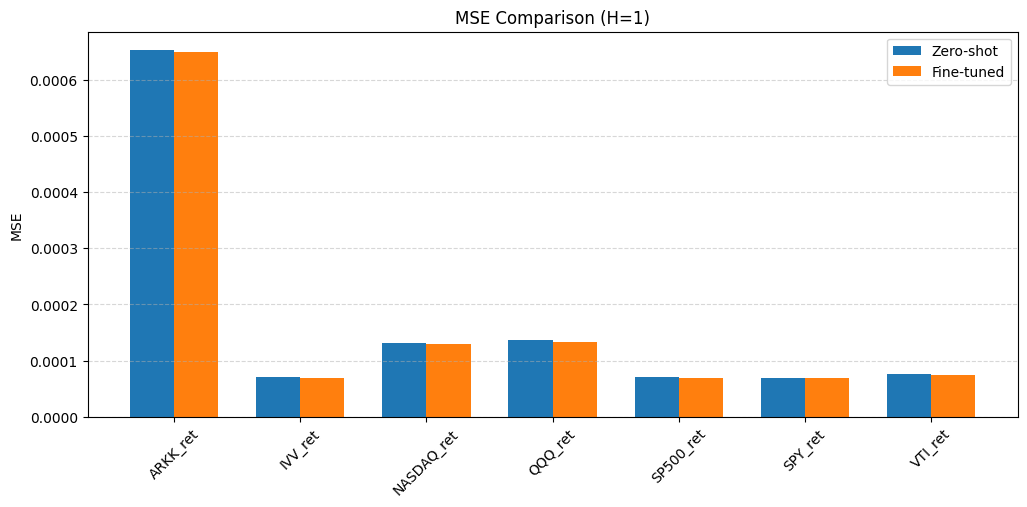

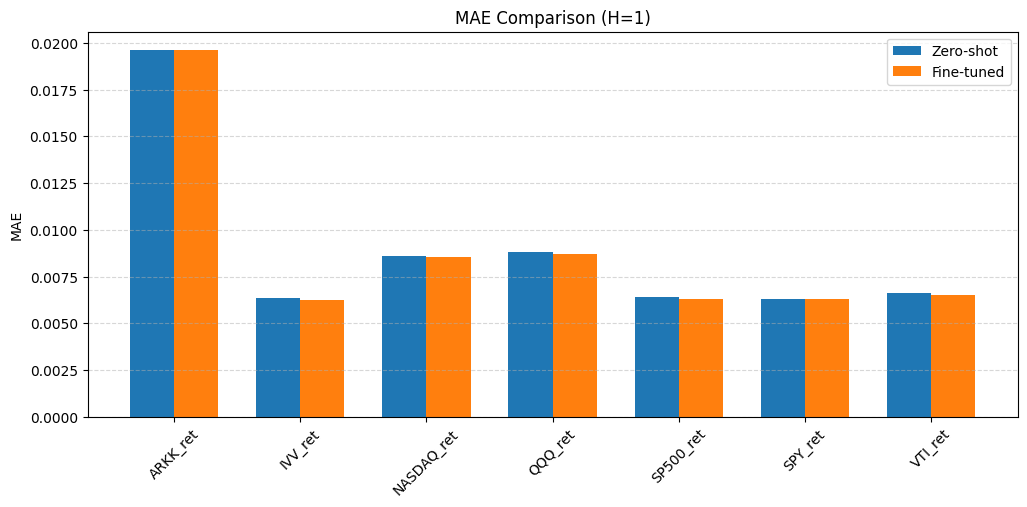

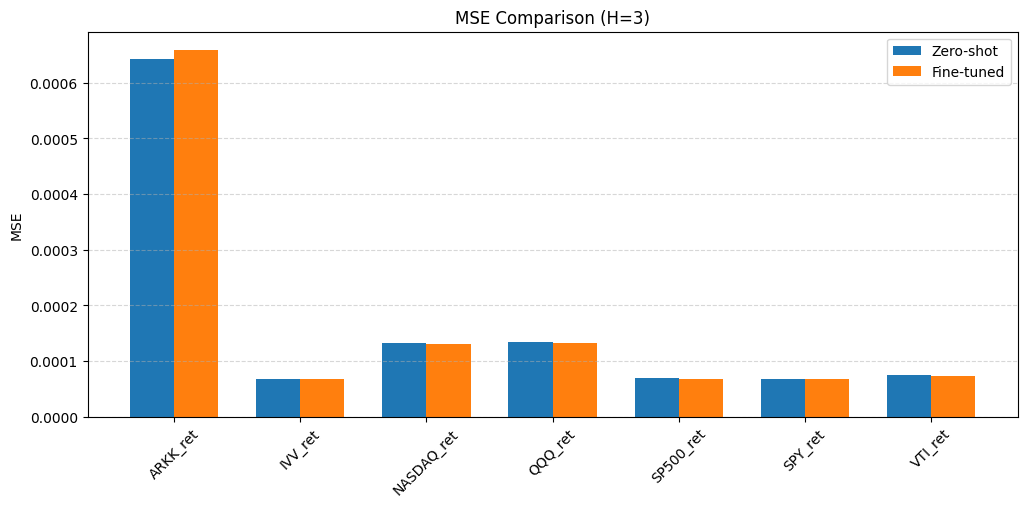

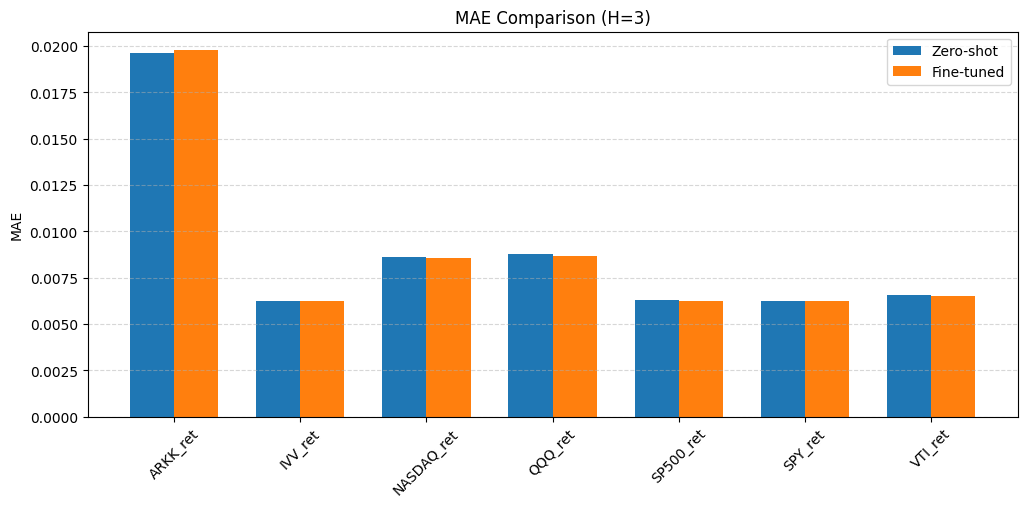

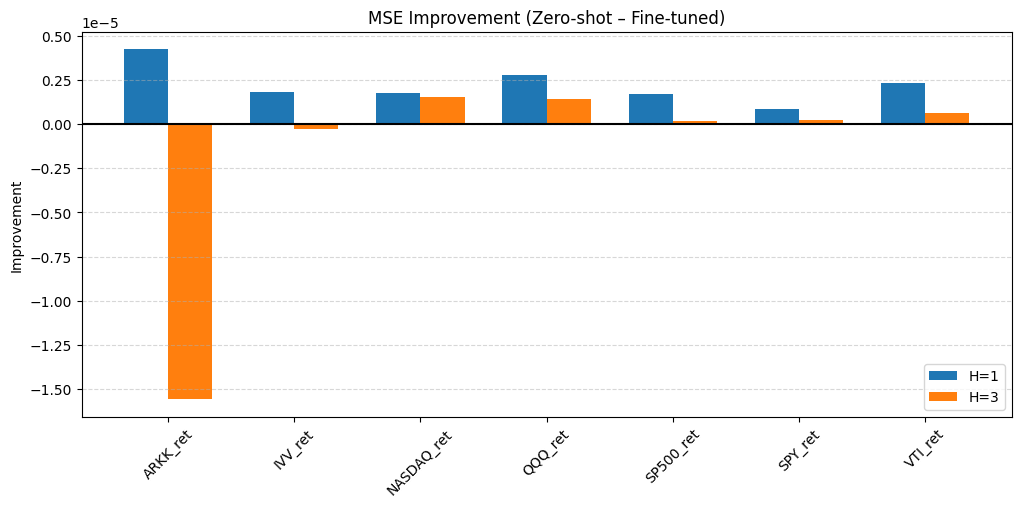

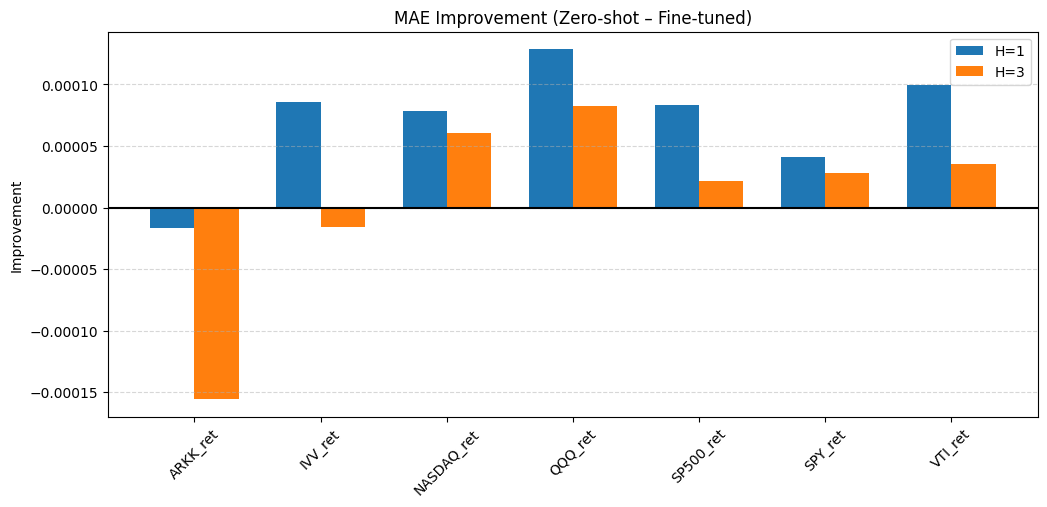

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ZERO_SHOT_METRIC = "/content/drive/MyDrive/Chronos_ZeroShot_L60/chronos_t5_small_L60_metrics_H1_H3.csv"
FT_METRICS_PATH  = "/content/drive/MyDrive/Chronos_Finetune_L60H3/chronos_t5_small_L60_finetuned_metrics_H1_H3.csv"

zero = pd.read_csv(ZERO_SHOT_METRIC)
ft   = pd.read_csv(FT_METRICS_PATH)

merged = zero.merge(ft, on=["asset", "horizon"], suffixes=("_zero", "_ft"))

# Compute improvements
merged["mse_improvement"] = merged["mse_zero"] - merged["mse_ft"]
merged["mae_improvement"] = merged["mae_zero"] - merged["mae_ft"]

assets = merged["asset"].unique()

def barplot(metric_zero, metric_ft, horizon, metric_name):
    plt.figure(figsize=(12,5))
    x = np.arange(len(assets))
    width = 0.35

    z_vals = merged[merged["horizon"] == horizon][metric_zero]
    f_vals = merged[merged["horizon"] == horizon][metric_ft]

    plt.bar(x - width/2, z_vals, width, label="Zero-shot")
    plt.bar(x + width/2, f_vals, width, label="Fine-tuned")

    plt.xticks(x, assets, rotation=45)
    plt.title(f"{metric_name} Comparison (H={horizon})")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

def improvement_plot(metric_name):
    plt.figure(figsize=(12,5))
    x = np.arange(len(assets))
    width = 0.35

    h1 = merged[merged["horizon"] == 1][f"{metric_name}_improvement"]
    h3 = merged[merged["horizon"] == 3][f"{metric_name}_improvement"]

    plt.bar(x - width/2, h1, width, label="H=1")
    plt.bar(x + width/2, h3, width, label="H=3")

    plt.xticks(x, assets, rotation=45)
    plt.title(f"{metric_name.upper()} Improvement (Zero-shot – Fine-tuned)")
    plt.ylabel("Improvement")
    plt.axhline(0, color='black')
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

# ------------------------------
# Generate all 5 figures
# ------------------------------

barplot("mse_zero", "mse_ft", horizon=1, metric_name="MSE")
barplot("mae_zero", "mae_ft", horizon=1, metric_name="MAE")

barplot("mse_zero", "mse_ft", horizon=3, metric_name="MSE")
barplot("mae_zero", "mae_ft", horizon=3, metric_name="MAE")

# Improvements
improvement_plot("mse")
improvement_plot("mae")
